# ML-Guided Arithmetic Circuit Optimization — Research Pipeline (v10)

```
Dataset → Parse → Normalize → DAG → Features → Local (v,r,C') Actions
  → GIN Rank (node × rule × confidence) → Top-K → Cost → PIT → Prune → Update → Loop
```

| # | Component |
|---|-----------|
| 1 | Explicit actions: node_id, rule, candidate_expr, candidate_graph |
| 2 | Training label: improvement = Score(C) − Score(C') |
| 3 | Cost: 0.40·S + 0.25·D + 0.15·M + 0.10·T + 0.10·G |
| 4–5 | Features: local/subtree/degree-to-output + estimated_blowup |
| 6 | PIT → Dead prune → Update DAG |
| 7 | GIN: R = σ(node)·p(rule)·σ(conf) |
| 8 | GIN before cost (top-K accelerator) |
| 9 | Beam search width 5 |
| 10 | Rule/node accuracy + score reduction metrics |



## Section 0 - Environment Setup

Run cells **0a - 0c** in order to setup the environment and load the imports.


In [15]:
import os
print(os.cpu_count())

16


In [16]:
# 0a - Setup checkpoint directory & verify device
from pathlib import Path
import torch
import os

try:
    CHECKPOINT_DIR = Path(__vsc_ipynb_file__).parent
except NameError:
    _cwd = Path(os.getcwd())
    if _cwd.name != "project" and (_cwd / "project").exists():
        CHECKPOINT_DIR = _cwd / "project"
    elif _cwd.name != "docs_IITK" and (_cwd / "docs_IITK").exists():
        CHECKPOINT_DIR = _cwd / "docs_IITK"
    else:
        CHECKPOINT_DIR = _cwd

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Local | PyTorch {torch.__version__} | cuda={torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
print(f"Checkpoints: {CHECKPOINT_DIR.resolve()}")


Local | PyTorch 1.14.0a0+410ce96 | cuda=True
  GPU: NVIDIA GeForce GTX 1080 Ti
Checkpoints: /data/project


In [17]:
# 0b - Fast install: skip what's already present; batch the rest
import subprocess, sys, time, importlib.util

def _installed(mod):
    return importlib.util.find_spec(mod) is not None

def _pip(pkgs, *extra_args):
    """Install one or more pip packages in a single call."""
    names = pkgs if isinstance(pkgs, (list, tuple)) else [pkgs]
    t0 = time.time()
    print(f"  pip install: {', '.join(names)}", flush=True)
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", *names, *extra_args, "-q"]
    )
    print(f"  Installed {len(names)} packages in {time.time() - t0:.1f}s")

_t_all = time.time()

BASE = [
    ("sympy", "sp"),
    ("networkx", "nx"),
    ("numpy", "np"),
    ("pandas", "pd"),
    ("matplotlib", "plt"),
    ("tqdm", "tqdm"),
    ("scikit-learn", "sklearn"),
    ("joblib", "joblib"),
]
missing_base = [pip for pip, mod in BASE if not _installed(mod)]
if missing_base:
    try:
        _pip(missing_base)
    except Exception as e:
        print(f"  Warning: base packages: {e}")
else:
    print("  base packages: already installed (skip)")

# PyG
if _installed("torch_geometric"):
    print("  torch-geometric: already installed (skip)")
else:
    try:
        _pip("torch-geometric")
    except Exception as e:
        print(f"  Warning: torch-geometric: {e}")

# dtreeviz is optional
if _installed("dtreeviz"):
    print("  dtreeviz: already installed (skip)")
else:
    print("  dtreeviz: optional - skipping here (install in Section 10 if you want fancy tree plots)")

print(f"Package setup complete ({time.time() - _t_all:.1f}s total)")


  pip install: sympy, networkx, numpy, pandas, matplotlib


  Installed 5 packages in 2.7s
  torch-geometric: already installed (skip)
  dtreeviz: already installed (skip)
Package setup complete (2.7s total)


In [18]:
import sympy as sp
from sympy import (symbols, Add, Mul, Pow, Integer, Float, Symbol,
                   Number, Rational, expand, factor, simplify,
                   collect, cancel, count_ops, cse, total_degree)
import networkx as nx
import numpy as np
import pandas as pd
import random, json, warnings, time, math, pickle, os
from pathlib import Path
import joblib
from copy import deepcopy
from collections import defaultdict
from functools import reduce
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

import torch, torch.nn as nn, torch.nn.functional as F
from torch.optim import Adam
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader as PyGLoader
from torch_geometric.nn import GINEConv, GINConv, global_mean_pool, global_add_pool

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

VARS = list(sp.symbols("x y z w u v a b c d e f"))
x, y, z, w, u, v = sp.symbols("x y z w u v")

RULE_NAMES = [
    "identity", "factorization", "distribution", "reassociation",
    "const_folding", "common_factor", "dead_pruning", "depth_reduction",
    "collection", "cse_rewrite",
]
N_RULES = len(RULE_NAMES)
GLOBAL_NODE_ID = -1

EDGE_TYPE = {"add_child":0, "mul_child":1, "pow_base":2, "pow_exp":3, "other":4}
EDGE_FEAT_DIM = 5

FEATURE_NAMES = [
    "gate_var","gate_const","gate_add","gate_mul","gate_pow","gate_other",
    "depth_from_root", "fan_in", "fan_out_norm", "subtree_size_norm",
    "is_shared",
    "local_degree", "subtree_degree", "degree_to_output",
    "depth_to_leaf", "op_density", "mul_ratio", "reuse_count",
    "estimated_blowup", "parent_op_type",
]
N_FEATURES = len(FEATURE_NAMES)

# Depth-first research weights
LAMBDA_SIZE, LAMBDA_DEPTH, LAMBDA_MUL, LAMBDA_TEMP, LAMBDA_DEG = 0.20, 0.50, 0.15, 0.10, 0.05

COST_PROFILES = {
    "depth_first":   (0.20, 0.50, 0.15, 0.10, 0.05),
    "size_first":    (0.40, 0.25, 0.15, 0.10, 0.10),
    "balanced":      (0.30, 0.35, 0.15, 0.10, 0.10),
}

GIN_TOP_K = 10
BEAM_WIDTH = 8
TOP_K_CANDIDATES = GIN_TOP_K
PIT_SMALL_NODES = 15
PIT_RANDOM_TRIALS = 30
PIT_PRIME = 2147483647
OPT_PATIENCE = 5
TRAIN_SUBSET_N = None

# --- Run scale & checkpointing ---
class DatasetConfig:
    """Dynamic dataset configuration.  Family quotas resolved lazily after
    FAMILY_BUILDERS is known (call .resolve(family_names) in Section 1)."""
    def __init__(self, total_samples, family_weights=None):
        self.total_samples = total_samples
        self._raw_weights = family_weights or {}
        self.split_quotas = {}          # filled by .resolve()

    def resolve(self, family_names):
        """Call once FAMILY_BUILDERS keys are available."""
        weights = {f: self._raw_weights.get(f, 1.0) for f in family_names}
        total_w = sum(weights.values()) or 1.0
        self.split_quotas = {
            f: max(1, int((w / total_w) * self.total_samples))
            for f, w in weights.items()
        }
        return self

config = DatasetConfig(total_samples=25000)
DATASET_TOTAL = config.total_samples   # backward-compat alias

N_EPOCHS = 15
if "CHECKPOINT_DIR" not in dir():
    try:
        # When running in VS Code, __vsc_ipynb_file__ contains the absolute path to the notebook
        CHECKPOINT_DIR = Path(__vsc_ipynb_file__).parent
    except NameError:
        # Fallback to current working directory
        import os
        _cwd = Path(os.getcwd())
        # If somehow we are in the parent directory of a 'project' or 'docs_IITK' folder containing the notebook, adjust
        if _cwd.name != "project" and (_cwd / "project").exists():
            CHECKPOINT_DIR = _cwd / "project"
        elif _cwd.name != "docs_IITK" and (_cwd / "docs_IITK").exists():
            CHECKPOINT_DIR = _cwd / "docs_IITK"
        else:
            CHECKPOINT_DIR = _cwd

CHECKPOINT_DIR = Path(CHECKPOINT_DIR)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESUME = True
PYG_SAVE_EVERY = 2_000          # save PyG corpus every N expressions
GIN_CKPT_EVERY_EPOCH = True    # checkpoint every epoch to prevent training loss on crash

def _ckpt(name):
    return CHECKPOINT_DIR / name

def save_pkl(obj, name):
    # Allow saving any pickle checkpoint file for the pipeline
    if not name.endswith(".pkl"):
        return
    p = _ckpt(name)
    with open(p, "wb") as f:
        pickle.dump(obj, f, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"  checkpoint saved: {p} ({p.stat().st_size / 1e6:.1f} MB)")

def load_pkl(name, default=None):
    p = _ckpt(name)
    if not RESUME or not p.exists():
        return default
    with open(p, "rb") as f:
        obj = pickle.load(f)
    print(f"  checkpoint loaded: {p}")
    return obj

def save_joblib_model(obj, name):
    # Do not save any joblib models (RF, Decision tree are skipped)
    return

def load_joblib_model(name, default=None):
    p = _ckpt(name)
    if not RESUME or not p.exists():
        return default
    obj = joblib.load(p)
    print(f"  checkpoint loaded: {p}")
    return obj

def save_gin_ckpt(model, optimizer, scheduler, epoch, history, fname="gin_latest.pt"):
    # Allow saving any gin checkpoint files (latest or epoch specific)
    if "epoch" in fname or not fname.endswith(".pt") or not fname.startswith("gin_"):
        return
    path = _ckpt(fname)
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "history": history,
    }, path)
    print(f"  GIN checkpoint: {path} (epoch {epoch})")

def load_gin_ckpt(model, optimizer, scheduler, device, fname="gin_latest.pt"):
    path = _ckpt(fname)
    if not RESUME or not path.exists():
        return 0, []
    try:
        ckpt = torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scheduler.load_state_dict(ckpt["scheduler_state"])
    ep = int(ckpt.get("epoch", 0))
    hist = ckpt.get("history", [])
    print(f"  resumed GIN from {path} @ epoch {ep}")
    return ep, hist

def pick_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = pick_device()

print(f"Imports OK | PyTorch {torch.__version__}")
print(f"  DATASET_TOTAL={DATASET_TOTAL:,}  N_EPOCHS={N_EPOCHS}  CHECKPOINT_DIR={CHECKPOINT_DIR.resolve()}")
print(f"  N_FEATURES={N_FEATURES}  GIN_TOP_K={GIN_TOP_K}  BEAM_WIDTH={BEAM_WIDTH}")
if DEVICE.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)} | CUDA {torch.version.cuda}")
elif DEVICE.type == "mps":
    print("  Device: Apple MPS (GPU)")
else:
    print("  ⚠️  Training device: CPU (slow for Section 7c)")
    if "+cpu" in torch.__version__ or not torch.version.cuda:
        print("     Likely cause: CPU-only PyTorch (+cpu build) or no GPU runtime.")
        print("     Local NVIDIA: pip install torch --index-url https://download.pytorch.org/whl/cu124")
print(f"  Cost weights: S={LAMBDA_SIZE} D={LAMBDA_DEPTH} M={LAMBDA_MUL} T={LAMBDA_TEMP} G={LAMBDA_DEG}")

Imports OK | PyTorch 1.14.0a0+410ce96
  DATASET_TOTAL=25,000  N_EPOCHS=15  CHECKPOINT_DIR=/data/project
  N_FEATURES=20  GIN_TOP_K=10  BEAM_WIDTH=8
  GPU: NVIDIA GeForce GTX 1080 Ti | CUDA 11.8
  Cost weights: S=0.2 D=0.5 M=0.15 T=0.1 G=0.05


---
## Section 1 - Phase 0: Dataset Generation 

> Checkpoints: `dataset_10k.pkl` - set `RESUME=True` to skip regeneration after a crash.

Four benchmark families. Each record stores:
`{expr, family, n_vars, degree, size, dag_size, shared_count, max_depth}` (approximate stats from SymPy at generation time).

> **Output:** Bar chart (count/family) + histograms of degree and circuit size.


In [19]:
class DatasetGenerator:
    def __init__(self, seed=42):
        import random
        import numpy as np
        self.rng = random.Random(seed)
        random.seed(seed)
        np.random.seed(seed)

    @staticmethod
    def _true_depth(expr):
        """Recursion depth of the SymPy expression tree."""
        if not getattr(expr, "args", []): return 0
        return 1 + max(DatasetGenerator._true_depth(a) for a in expr.args)

    @staticmethod
    def _graph_meta(expr):
        import sympy as sp
        from sympy import count_ops
        try:
            expanded = sp.expand(expr)
            dag_size = count_ops(expanded)
            syms = list(expanded.free_symbols)
            shared_count = max(0, dag_size - len(syms) - 2)
            poly_degree = int(sp.total_degree(expanded))
            true_depth = DatasetGenerator._true_depth(expr)
            return int(dag_size), int(shared_count), int(true_depth), int(poly_degree)
        except Exception:
            return 0, 0, 0, 0

    def _make_rec(self, expr, family):
        import sympy as sp
        from sympy import count_ops
        free = expr.free_symbols
        try: 
            deg = int(sp.total_degree(expr))
        except: 
            deg = -1
            
        dag_size, shared_count, true_depth, poly_degree = self._graph_meta(expr)
        
        try:
            G_tmp = DAGConverter().convert(ExprNormalizer().normalize_for_cost(expr))
            circ_depth = DAGConverter.circuit_depth(G_tmp)
        except:
            circ_depth = true_depth
            
        return {
            "expr": expr,
            "family": family,
            "str_repr": str(expr),
            "n_vars": len(free),
            "degree": deg,
            "size": count_ops(expr),
            "dag_size": dag_size,
            "shared_count": shared_count,
            "true_depth": true_depth,
            "max_depth": poly_degree,
            "circuit_depth": circ_depth,
        }

    def generate(self, n_per_family=4167, DEPTH_FILTER=None):
        import sympy as sp
        x, y, z, w, u, v, a, b, c, d, e, f = sp.symbols("x y z w u v a b c d e f")

        def gen_cse_heavy(rng):
            s = rng.choice([x+y, y+z, a+b, c+d])
            vs = rng.sample([x,y,z,w,u,v,a,b,c,d,e,f], 4)
            return s*(vs[0]+vs[1]) + s*(vs[2]+vs[3])

        def gen_depth_heavy(rng):
            vars_ = rng.sample([x, y, z, w, u, v, a, b, c, d, e, f], 8)
            return (vars_[0]+vars_[1])*(vars_[2]+vars_[3]) + (vars_[4]+vars_[5])*(vars_[6]+vars_[7])

        def gen_common_factor_heavy(rng):
            s = rng.choice([x, y, z, a, b])
            return s*a + s*b + s*c + s*d

        def gen_multi_step_chain(rng):
            s1 = rng.choice([x+y, y+z, a+b, c+d])
            s2 = rng.choice([x+y, y+z, a+b, c+d])
            return s1* u + s1* v + s2 * u + s2 * v

        def gen_distrib_recovery(rng):
            p = rng.choice([x+y, a+b, c+d])
            q = rng.choice([u+v, w+z, e+f])
            return p*q + p*(q + 1)

        def gen_reassoc_heavy(rng):
            vars_ = rng.sample([x, y, z, w, u, v, a, b, c, d, e, f], 8)
            return ((vars_[0]+vars_[1])*(vars_[2]+vars_[3])) * ((vars_[4]+vars_[5])*(vars_[6]+vars_[7]))

        def gen_const_fold_target(rng):
            return (rng.randint(2,5) + rng.randint(1,4)) * x + (rng.randint(1,3) * rng.randint(2,4)) * y + z

        def gen_depth_reduction_target(rng):
            vs = rng.sample([x,y,z,w,u,v,a,b], 6)
            expr = vs[0]
            for t in vs[1:]:
                expr = expr + t
            return expr

        def gen_common_factor_target(rng):
            base = rng.choice([x, y, z, a, b])
            others = rng.sample([x,y,z,w,u,v], 4)
            return sp.Add(*[base * o for o in others])

        def gen_reassoc_target(rng):
            vs = rng.sample([x, y, z, w, u, v, a, b], 8)
            left = sp.Mul(vs[0]+vs[1], vs[2]+vs[3], evaluate=False)
            right = sp.Mul(vs[4]+vs[5], vs[6]+vs[7], evaluate=False)
            return sp.Add(left, right, evaluate=False)

        def gen_depth3_target(rng):
            vs = rng.sample([x,y,z,w,u,v,a,b], 4)
            ops = [sp.Add, sp.Mul]
            root_op  = rng.choice(ops)
            left_op  = rng.choice(ops)
            right_op = rng.choice(ops)
            left  = left_op( vs[0], vs[1])
            right = right_op(vs[2], vs[3])
            return root_op(left, right, evaluate=False)

        def gen_depth3_circuit(rng):
            vs = rng.sample([x,y,z,w,u,v,a,b,c,d,e,f], 6)
            shared = vs[0] + vs[1]
            return shared * vs[2] + shared * vs[3]

        def gen_depth3_mul_sum(rng):
            vs = rng.sample([x,y,z,w,u,v,a,b,c,d,e,f], 6)
            lhs = (vs[0] + vs[1]) * (vs[2] + vs[3])
            rhs = (vs[0] + vs[1]) * (vs[4] + vs[5])
            return lhs + rhs

        def gen_depth3_factored(rng):
            vs = rng.sample([x,y,z,w,u,v,a,b,c,d,e,f], 5)
            shared = vs[0] + vs[1]
            return vs[2]*shared + vs[3]*shared + vs[4]*shared

        def gen_depth3_reassoc(rng):
            vs = rng.sample([x,y,z,w,u,v,a,b], 4)
            inner = sp.Add(vs[0], vs[1], evaluate=False)
            mid   = sp.Add(inner, vs[2], evaluate=False)
            outer = sp.Add(mid, vs[3], evaluate=False)
            return outer

        FAMILY_BUILDERS = {
            "factorization_heavy": gen_common_factor_heavy,
            "cse_heavy":           gen_cse_heavy,
            "depth_heavy":         gen_depth_heavy,
            "multi_step_chain":    gen_multi_step_chain,
            "distrib_recovery":    gen_distrib_recovery,
            "reassoc_heavy":       gen_reassoc_heavy,
            "const_fold_target":   gen_const_fold_target,
            "depth_reduction_target": gen_depth_reduction_target,
            "common_factor_target":   gen_common_factor_target,
            "reassoc_target":         gen_reassoc_target,
            "depth3_circuit":      gen_depth3_circuit,
            "depth3_mul_sum":      gen_depth3_mul_sum,
            "depth3_factored":     gen_depth3_factored,
            "depth3_reassoc":      gen_depth3_reassoc,
        }

        dataset = []
        n_per_family = int((n_per_family * 6) / len(FAMILY_BUILDERS))
        
        for fam, builder in FAMILY_BUILDERS.items():
            print(f"  {fam:<24} {n_per_family:>6,} ...", end=" ", flush=True)
            import time
            t0 = time.time()
            count = 0
            attempts = 0
            
            while count < n_per_family and attempts < n_per_family * 20:
                attempts += 1
                try: 
                    raw_expr = builder(self.rng)
                    dataset.append(self._make_rec(raw_expr, fam))
                    count += 1
                except: 
                    pass
            print(f"({time.time()-t0:.1f}s) -> added {count}")

        self.rng.shuffle(dataset)
        print(f"\nTotal: {len(dataset):,}")
        return dataset

In [20]:
DEPTH_FILTER = 3
# DatasetConfig defined in Section 0 — do NOT redefine here.
# Resolve family quotas now that DatasetGenerator (and its FAMILY_BUILDERS) is available.
gen = DatasetGenerator(SEED)
_family_names = list(gen._get_family_builders().keys()) if hasattr(gen, '_get_family_builders') else []
if _family_names:
    config.resolve(_family_names)
DATASET_TOTAL = config.total_samples   # keep alias in sync

DATASET_CKPT = "dataset_25k_depth3.pkl"
dataset = load_pkl(DATASET_CKPT)

if dataset is None:
    print(f"Generating expressions for depth-{DEPTH_FILTER} filter | target={DATASET_TOTAL:,}")
    # Use dynamic per-family quotas from DatasetConfig
    dataset = gen.generate_from_config(config, DEPTH_FILTER=DEPTH_FILTER)
    import random
    random.shuffle(dataset)
    dataset = dataset[:DATASET_TOTAL]
    save_pkl(dataset, DATASET_CKPT)
    print(f"Final depth-{DEPTH_FILTER} dataset: {len(dataset):,}")
else:
    print(f"Resumed dataset from checkpoint: {len(dataset):,} expressions")

  checkpoint loaded: dataset_25k_depth3.pkl
Resumed dataset from checkpoint: 25,000 expressions


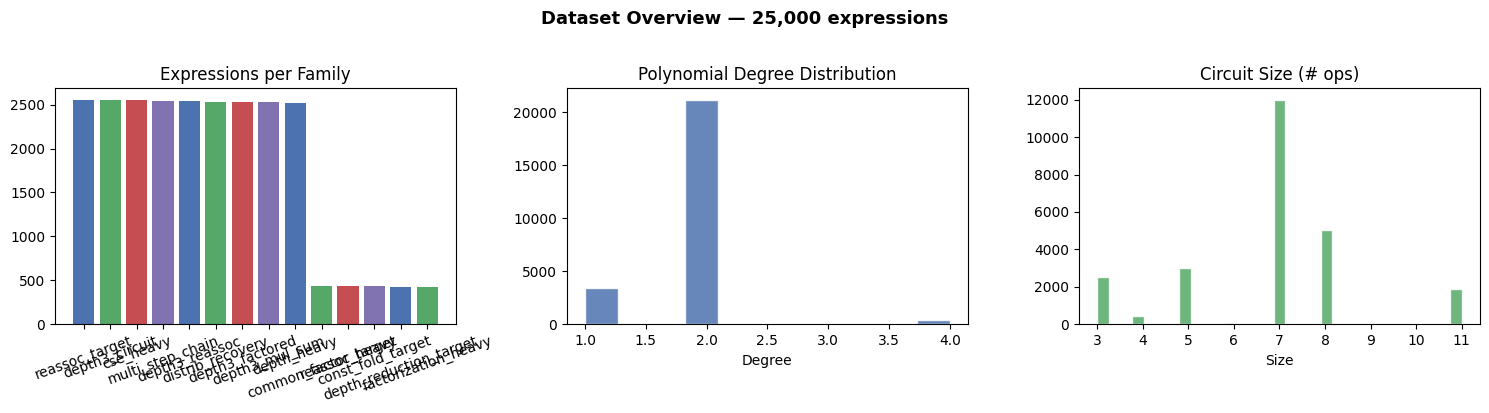

                        size  degree  n_vars
family                                      
common_factor_target    7.00     2.0    4.57
const_fold_target       4.00     1.0    3.00
cse_heavy               6.97     2.0    5.33
depth3_circuit          5.00     2.0    4.00
depth3_factored         8.00     2.0    5.00
depth3_mul_sum          7.00     2.0    6.00
depth3_reassoc          3.00     1.0    4.00
depth_heavy             7.00     2.0    8.00
depth_reduction_target  5.00     1.0    6.00
distrib_recovery        8.00     2.0    4.00
factorization_heavy     7.00     2.0    4.64
multi_step_chain        9.98     2.0    5.36
reassoc_heavy           7.00     4.0    8.00
reassoc_target          7.00     2.0    8.00


In [21]:
df_meta = pd.DataFrame([{k:v for k,v in r.items() if k!="expr"} for r in dataset])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fc = df_meta["family"].value_counts()
axes[0].bar(fc.index, fc.values, color=["#4C72B0","#55A868","#C44E52","#8172B2"])
axes[0].set_title("Expressions per Family"); axes[0].tick_params(axis="x", rotation=20)
axes[1].hist(df_meta["degree"].clip(0, 10), bins=11, color="#4C72B0", alpha=0.85, edgecolor="w")
axes[1].set_title("Polynomial Degree Distribution"); axes[1].set_xlabel("Degree")
axes[2].hist(df_meta["size"].clip(0, 30), bins=31, color="#55A868", alpha=0.85, edgecolor="w")
axes[2].set_title("Circuit Size (# ops)"); axes[2].set_xlabel("Size")
plt.suptitle(f"Dataset Overview — {len(dataset):,} expressions", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()
print(df_meta.groupby("family")[["size","degree","n_vars"]].mean().round(2))


---
## 🌲 Section 2 — Phase 1: Parsing → AST

SymPy handles tokenisation, associative flattening, and commutative ordering.

> **Output:** Hierarchical tree print. `[add]` / `[mul]` nodes show operator structure
> before any DAG sharing. Depth tells us how nested the computation is.


In [22]:
class ASTParser:
    @staticmethod
    def _nt(e):
        if isinstance(e, sp.Symbol): return "var"
        if isinstance(e, (sp.Integer, sp.Float, sp.Rational, sp.Number)): return "const"
        if isinstance(e, sp.Add): return "add"
        if isinstance(e, sp.Mul): return "mul"
        if isinstance(e, sp.Pow): return "pow"
        return "other"

    def _build(self, e):
        nt = self._nt(e)
        lbl = str(e) if nt in ("var","const") else nt
        return {"type": nt, "label": lbl, "expr": e,
                "children": [self._build(a) for a in e.args] if e.args else []}

    def parse_expr(self, e): return self._build(e)

    def parse_string(self, s):
        lv = {str(v): v for v in VARS}
        return self._build(sp.sympify(s, locals=lv))

    def ast_to_nx(self, ast):
        G = nx.DiGraph(); ctr = [0]
        def _a(node):
            nid = ctr[0]; ctr[0] += 1
            G.add_node(nid, **{k: v for k,v in node.items() if k != "children"})
            for ch in node["children"]: G.add_edge(nid, _a(ch))
            return nid
        G.graph["root"] = _a(ast); return G

    @staticmethod
    def print_ast(ast, indent=0):
        print("  "*indent + f"[{ast['type']}] {ast['label']}")
        for ch in ast["children"]: ASTParser.print_ast(ch, indent+1)

parser = ASTParser()
test_expr = (x+y)*z + (x+y)*w + (u+v)*z + (2+3)*x
ast = parser.parse_expr(test_expr)
print("=== AST for: (x+y)*z + (x+y)*w + (u+v)*z + (2+3)*x ===\n")
ASTParser.print_ast(ast)
G_ast = parser.ast_to_nx(ast)
print(f"\nNodes={G_ast.number_of_nodes()} Edges={G_ast.number_of_edges()}")
print("→ Tree (no sharing). DAG conversion will merge the two (x+y) occurrences.")


=== AST for: (x+y)*z + (x+y)*w + (u+v)*z + (2+3)*x ===

[add] add
  [mul] mul
    [const] 5
    [var] x
  [mul] mul
    [var] w
    [add] add
      [var] x
      [var] y
  [mul] mul
    [var] z
    [add] add
      [var] u
      [var] v
  [mul] mul
    [var] z
    [add] add
      [var] x
      [var] y

Nodes=19 Edges=18
→ Tree (no sharing). DAG conversion will merge the two (x+y) occurrences.


---
## 🧹 Section 3 — Phase 2: Normalization

Constant folding → identity removal → expand → collect.

> **Output:** Before/after table. Δsize column shows ops saved.


In [23]:
class ExprNormalizer:
    @staticmethod
    def constant_fold(e):
        if not e.free_symbols:
            try:
                v = float(e)
                return sp.Integer(int(v)) if v == int(v) else sp.Float(v)
            except:
                return e
        return e.func(*[ExprNormalizer.constant_fold(a) for a in e.args]) if e.args else e

    @staticmethod
    def remove_identities(e):
        if isinstance(e, sp.Add):
            args = [ExprNormalizer.remove_identities(a) for a in e.args if a != sp.S.Zero]
            return sp.Add(*args) if args else sp.S.Zero
        if isinstance(e, sp.Mul):
            if sp.S.Zero in e.args:
                return sp.S.Zero
            args = [ExprNormalizer.remove_identities(a) for a in e.args if a != sp.S.One]
            return sp.Mul(*args) if args else sp.S.One
        if isinstance(e, sp.Pow):
            b, ex = e.args
            if ex == 0:
                return sp.S.One
            if ex == 1:
                return ExprNormalizer.remove_identities(b)
            return sp.Pow(ExprNormalizer.remove_identities(b), ex)
        return e

    def normalize_for_cost(self, e):
        s = self.constant_fold(e)
        s = self.remove_identities(s)
        return s

    def normalize_for_display(self, e):
        s = self.constant_fold(e)
        s = self.remove_identities(s)
        s = sp.expand(s)
        s = sp.collect(s, s.free_symbols)
        return s

normalizer = ExprNormalizer()

examples = [
    (x+y)*z + (x+y)*w + (u+v)*z + (2+3)*x,
    x*0 + y*1 + z + 0,
    (x+0)*(1+y)*(z+0),
    (3+4)*x + (1+1)*y,
]
print(f"{'Original':<45}  →  {'Normalized':<38}  Δsize")
print("-" * 100)
for e in examples:
    n = normalizer.normalize_for_display(e)
    delta = count_ops(e) - count_ops(n)
    flag = f"−{delta}" if delta > 0 else ("0" if delta == 0 else f"+{-delta}")
    print(f"{str(e):<45}  →  {str(n):<38}  {flag}")

def verify_no_normalization_collapse():
    e = x*y + x*z
    f = sp.factor(e)
    n = ExprNormalizer().normalize_for_cost(f)
    assert n == f or count_ops(n) <= count_ops(f), \
        f"Normalization reverted factorization: {f} -> {n}"
    print("✅ Normalization round-trip OK")
verify_no_normalization_collapse()


Original                                       →  Normalized                              Δsize
----------------------------------------------------------------------------------------------------
w*(x + y) + 5*x + z*(u + v) + z*(x + y)        →  u*z + v*z + w*(x + y) + 5*x + z*(x + y)  +1
y + z                                          →  y + z                                   0
x*z*(y + 1)                                    →  z*(x*y + x)                             0
7*x + 2*y                                      →  7*x + 2*y                               0
✅ Normalization round-trip OK


---
## 🕸️ Section 4 — Phase 3: DAG Conversion with Edge Types

**New in v3:** Each edge carries a 5-dim one-hot `edge_type` attribute:

| Code | Meaning |
|------|---------|
| 0 | `add_child` — this operand is an addend |
| 1 | `mul_child` — this operand is a factor |
| 2 | `pow_base`  — this operand is the base of a power |
| 3 | `pow_exp`   — this operand is the exponent |
| 4 | `other`     — generic |

> **Output:** Node count ≤ AST count (CSE sharing). Coloured DAG graph shows gate types.


In [24]:
class PipelineCaches:
    def __init__(self):
        self.candidate_cache = {}
        self.cost_cache = {}
        self.pit_cache = {}
        self.dag_cache = {}
        self.config_version = "v1"

pipeline_caches = PipelineCaches()

def _process_one_record(rec_str_repr, gin_top_k):
    import sympy as sp
    try:
        expr = sp.sympify(rec_str_repr["str_repr"])
    except Exception:
        return []

    local_norm = ExprNormalizer()
    local_dc = DAGConverter()
    local_cg = CandidateGenerator()
    local_cm = CostModel()
    local_fe = FeatureExtractor()

    try:
        norm = local_norm.normalize_for_cost(expr)
        G_d = local_dc.convert(norm)
        if G_d.number_of_nodes() < 2:
            return []
        actions = local_cg.generate_all_actions(norm, G_d)
        if not actions:
            return []
        labeled = local_cg.label_candidates(norm, actions, G_d, local_cm)
        supervised = local_cg.annotate_supervision(labeled, top_k=gin_top_k)

        out = []
        for item in supervised:
            data = local_fe.to_pyg_data(
                G_d,
                target_node=item["node_id"],
                target_rule=item["rule_idx"],
                improvement=item["improvement"],
                node_reducible=item["node_reducible"],
                confidence=item["confidence"],
                in_top_k=item["in_top_k"],
            )
            out.append((item.get("rule_idx", -1), float(item.get("improvement", 0.0)), data))
        return out
    except Exception:
        return []


class DAGConverter:
    """Arithmetic DAG with hash-based CSE + 5-dim edge-type features."""

    def __init__(self): 
        self._reset()
        
    def _reset(self): 
        self._ctr = 0
        self._memo = {}

    @staticmethod
    def _gate_type(e):
        if isinstance(e, sp.Symbol): return "var"
        if isinstance(e, (sp.Integer, sp.Float, sp.Rational, sp.Number)): return "const"
        if isinstance(e, sp.Add): return "add"
        if isinstance(e, sp.Mul): return "mul"
        if isinstance(e, sp.Pow): return "pow"
        return "other"

    @staticmethod
    def _edge_type(parent_gtype, child_index):
        if parent_gtype == "add": return 0
        if parent_gtype == "mul": return 1
        if parent_gtype == "pow": return 2 if child_index == 0 else 3
        return 4

    def _add(self, G, expr):
        key = hash(expr)
        if key in self._memo: 
            return self._memo[key]
            
        nid = self._ctr
        self._ctr += 1
        gt = self._gate_type(expr)
        lbl = str(expr) if gt in ("var", "const") else {"add": "+", "mul": "×", "pow": "^"}.get(gt, gt)
        
        G.add_node(nid, node_type=gt, label=lbl, expr=expr, fan_out=0)
        self._memo[key] = nid
        
        for i, arg in enumerate(expr.args or []):
            cid = self._add(G, arg)
            et = self._edge_type(gt, i)
            G.add_edge(nid, cid, edge_type=et)
            G.nodes[cid]["fan_out"] = G.nodes[cid].get("fan_out", 0) + 1
            
        return nid

    @staticmethod
    def circuit_depth(G):
        if G.number_of_nodes() == 0: return 0
        root = G.graph.get("root", next(iter(nx.topological_sort(G))))
        depths = nx.single_source_shortest_path_length(G, root)
        return max(depths.values(), default=0)

    def convert(self, expr):
        key = hash(expr)
        if key in pipeline_caches.dag_cache:
            return pipeline_caches.dag_cache[key]
            
        self._reset()
        G = nx.DiGraph()
        root = self._add(G, expr)
        G.graph["root"] = root
        
        pipeline_caches.dag_cache[key] = G
        return G

    @staticmethod
    def dag_size(G):
        return sum(1 for n in G.nodes() if G.nodes[n]["node_type"] in ("add", "mul", "pow"))

    @staticmethod
    def shared_nodes(G):
        return [n for n in G.nodes() if G.nodes[n].get("fan_out", 0) > 1]

    @staticmethod
    def visualize(G, title="Arithmetic DAG", figsize=(9, 5)):
        cmap = {
            "add": "#AED6F1", "mul": "#A9DFBF", "var": "#FAD7A0",
            "const": "#F1948A", "pow": "#D7BDE2", "other": "#BFC9CA"
        }
        colors = [cmap.get(G.nodes[n]["node_type"], "#BFC9CA") for n in G.nodes()]
        labels = {n: G.nodes[n]["label"] for n in G.nodes()}
        
        # Hierarchical layout — no graphviz dependency
        pos = DAGConverter._hierarchical_pos(G, G.graph.get("root", next(iter(nx.topological_sort(G)))))
            
        legend = [mpatches.Patch(color=c, label=t) for t, c in cmap.items() if t != "other"]
        
        plt.figure(figsize=figsize)
        nx.draw(G, pos, labels=labels, node_color=colors, node_size=900,
                font_size=9, arrows=True, arrowsize=14, edge_color="#55", width=1.5)
                
        edge_labels = {}
        for u, v, d in G.edges(data=True):
            et = d.get("edge_type", 4)
            edge_labels[(u, v)] = ["add", "mul", "base", "exp", "?"][min(et, 4)]
            
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                     font_size=6, font_color="#333", label_pos=0.35)
                                     
        plt.legend(handles=legend, loc="upper right", fontsize=8)
        plt.title(title, fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()

    @staticmethod
    def _hierarchical_pos(G, root, width=1.0, vert_gap=1.0):
        """
        Pure-Python Reingold-Tilford style hierarchical layout.
        No graphviz dependency.  Returns {node: (x, y)} with root at top.
        """
        def _recurse(n, left, right, depth, pos):
            children = list(G.successors(n))
            if not children:
                mid = (left + right) / 2.0
                pos[n] = (mid, -depth)
                return mid
            step = (right - left) / len(children)
            mids = []
            for i, child in enumerate(children):
                mid = _recurse(child, left + i * step, left + (i + 1) * step, depth + 1, pos)
                mids.append(mid)
            my_x = (mids[0] + mids[-1]) / 2.0
            pos[n] = (my_x, -depth)
            return my_x

        pos = {}
        _recurse(root, 0, width, 0, pos)
        return pos

    @staticmethod
    def draw_as_tree(G, title="Circuit Tree", figsize=(10, 6), ax=None):
        """
        DSA / ML-textbook style tree: root at top, children below.
        Pure-matplotlib — no graphviz required.
        """
        CMAP = {"add": "#AED6F1", "mul": "#A9DFBF", "var": "#FAD7A0",
                "const": "#F1948A", "pow": "#D7BDE2", "other": "#E8E8E8"}
        OP_LABEL = {"add": "+", "mul": "×", "pow": "^"}

        T = nx.DiGraph()
        def _unroll(n_dag, parent_tree=None):
            n_tree = len(T.nodes)
            nd  = G.nodes[n_dag]
            gt  = nd.get("node_type", "other")
            lbl = OP_LABEL.get(gt, nd.get("label", "?"))
            T.add_node(n_tree, label=lbl, color=CMAP.get(gt, "#E8E8E8"), gt=gt)
            if parent_tree is not None:
                T.add_edge(parent_tree, n_tree)
            for child in G.successors(n_dag):
                _unroll(child, n_tree)

        root_dag  = G.graph.get("root", next(iter(nx.topological_sort(G))))
        _unroll(root_dag)
        root_tree = 0

        pos    = DAGConverter._hierarchical_pos(T, root_tree, width=max(T.number_of_nodes(), 4))
        colors = [T.nodes[n]["color"] for n in T.nodes()]
        labels = {n: T.nodes[n]["label"] for n in T.nodes()}

        show = ax is None
        if show:
            fig, ax = plt.subplots(figsize=figsize)

        nx.draw(T, pos, labels=labels, node_color=colors, node_size=1400,
                font_size=10, font_weight="bold", arrows=True, arrowsize=16,
                arrowstyle="-|>", edge_color="#555", width=1.8, ax=ax)

        legend = [mpatches.Patch(color=c, label=t)
                  for t, c in CMAP.items() if t != "other"]
        ax.legend(handles=legend, loc="upper right", fontsize=9, framealpha=0.9)
        ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
        if show:
            plt.tight_layout()
            plt.show()

def compare_circuits(expr1, expr2, title1="Original", title2="Optimized"):
    """Side-by-side before/after tree comparison — DSA textbook style."""
    dc   = DAGConverter()
    norm = ExprNormalizer()
    G1   = dc.convert(norm.normalize_for_cost(expr1))
    G2   = dc.convert(norm.normalize_for_cost(expr2))

    m1 = CostModel.graph_metrics(G1) if hasattr(CostModel, 'graph_metrics') else {}
    m2 = CostModel.graph_metrics(G2) if hasattr(CostModel, 'graph_metrics') else {}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    DAGConverter.draw_as_tree(
        G1, title=f"{title1}\nOps={count_ops(expr1)}  Depth={m1.get('depth','?')}", ax=ax1)
    DAGConverter.draw_as_tree(
        G2, title=f"{title2}\nOps={count_ops(expr2)}  Depth={m2.get('depth','?')}", ax=ax2)

    plt.suptitle("Circuit Before vs After Optimization",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

    print(f"  [{title1}] ops={count_ops(expr1)}  size={m1.get('size','?')}  depth={m1.get('depth','?')}")
    print(f"  [{title2}] ops={count_ops(expr2)}  size={m2.get('size','?')}  depth={m2.get('depth','?')}")
    if m1 and m2:
        print(f"  Δsize={m1.get('size',0)-m2.get('size',0)}  Δdepth={m1.get('depth',0)-m2.get('depth',0)}")

---
## 📐 Section 5 — Phase 4: Feature Extraction (20-dim nodes + 5-dim edges)

**v3 adds 5 new node features** to the original 12:

| # | Feature | Why it matters |
|---|---------|----------------|
| 12 | `depth_to_leaf` | How far from a leaf — high = internal op, good rewrite target |
| 13 | `op_density` | ops-in-subtree / subtree_size — dense subtrees benefit from factorisation |
| 14 | `mul_ratio` | mul_gates / subtree_size — multiplication-heavy → factorisation likely wins |
| 15 | `reuse_count` | raw fan_out (exact reuse frequency, not normalised) |
| 16 | `global_degree` | feature only (not an optimization target) |

> **Output:** Table showing the full 20-dim vector per node.


In [25]:
class FeatureExtractor:
    """20-dim node features including degree + estimated blowup + parent_op_type."""
    GATE_TYPES = {"var":0,"const":1,"add":2,"mul":3,"pow":4,"other":5}
    N_TYPES = 6
    N_FEATURES = len(FEATURE_NAMES)
    EDGE_FEAT_DIM = EDGE_FEAT_DIM

    @staticmethod
    def _bfs_depths(G, root):
        return dict(nx.single_source_shortest_path_length(G, root))

    @staticmethod
    def _depth_to_output(G, root):
        rev = G.reverse(copy=False)
        return dict(nx.single_source_shortest_path_length(rev, root))

    @staticmethod
    def _subtree_sizes(G):
        sz = {}
        for n in reversed(list(nx.topological_sort(G))):
            ch = list(G.successors(n))
            sz[n] = 1 + sum(sz.get(c, 1) for c in ch)
        return sz

    @staticmethod
    def _subtree_muls(G):
        muls = {}
        for n in reversed(list(nx.topological_sort(G))):
            ch = list(G.successors(n))
            mine = 1 if G.nodes[n].get("node_type") == "mul" else 0
            muls[n] = mine + sum(muls.get(c, 0) for c in ch)
        return muls

    @staticmethod
    def _subtree_ops(G):
        ops = {}
        for n in reversed(list(nx.topological_sort(G))):
            ch = list(G.successors(n))
            mine = 1 if G.nodes[n].get("node_type") not in ("var", "const") else 0
            ops[n] = mine + sum(ops.get(c, 0) for c in ch)
        return ops

    @staticmethod
    def _depth_to_leaf(G):
        dtl = {}
        for n in nx.topological_sort(G):
            ch = list(G.successors(n))
            dtl[n] = 0 if not ch else 1 + max(dtl.get(c, 0) for c in ch)
        return dtl

    @staticmethod
    def _poly_degree(expr):
        if expr is None:
            return 0.0
        try:
            return float(min(int(sp.total_degree(expr)), 12))
        except Exception:
            return 0.0

    @staticmethod
    def _local_degree(G, n):
        nt = G.nodes[n].get("node_type", "other")
        if nt == "mul":
            return float(G.out_degree(n))
        if nt == "pow":
            for c in G.successors(n):
                if G.nodes[c].get("node_type") == "const":
                    try:
                        return float(abs(G.nodes[c].get("expr", 2.0)))
                    except Exception:
                        return 2.0
            return 2.0
        return 1.0

    @staticmethod
    def _subtree_max_degree(G, n):
        degs = [FeatureExtractor._poly_degree(G.nodes[x].get("expr"))
                for x in nx.descendants(G, n)]
        degs.append(FeatureExtractor._poly_degree(G.nodes[n].get("expr")))
        return max(degs, default=0.0)

    @staticmethod
    def _estimated_blowup(G, n, sizes):
        nt = G.nodes[n].get("node_type", "other")
        sz = sizes.get(n, 1)
        mx = max(sizes.values(), default=1)
        if nt == "mul":
            return float(np.clip(sz / mx * 1.5, 0, 1))
        if nt == "add" and sz > 3:
            return float(np.clip(0.3 + sz / mx, 0, 1))
        return float(np.clip(sz / (2 * mx), 0, 0.5))

    def extract(self, G):
        root = G.graph.get("root", next(iter(nx.topological_sort(G))))
        depths_root = self._bfs_depths(G, root)
        depths_out = self._depth_to_output(G, root)
        sizes = self._subtree_sizes(G)
        muls = self._subtree_muls(G)
        ops = self._subtree_ops(G)
        dtl = self._depth_to_leaf(G)

        mx_d = max(depths_root.values(), default=1) or 1
        mx_do = max(depths_out.values(), default=1) or 1
        mx_sz = max(sizes.values(), default=1) or 1
        mx_fo = max((G.in_degree(n) for n in G.nodes()), default=1) or 1
        mx_fi = max((G.out_degree(n) for n in G.nodes()), default=1) or 1
        mx_dtl = max(dtl.values(), default=1) or 1
        mx_subdeg = 12.0

        node_list = sorted(G.nodes())
        rows = []
        for n in node_list:
            nd = G.nodes[n]
            gt = nd.get("node_type", "other")
            oh = [0] * 6
            oh[self.GATE_TYPES.get(gt, 5)] = 1
            sz_n = sizes.get(n, 1)
            raw_fo = G.in_degree(n)
            
            parent_op_type = 5.0
            parents = list(G.predecessors(n))
            if parents:
                pt = G.nodes[parents[0]].get("node_type", "other")
                parent_op_type = float(self.GATE_TYPES.get(pt, 5))
            parent_op_norm = parent_op_type / max(self.N_TYPES - 1, 1)

            feat = oh + [
                depths_root.get(n, 0) / mx_d,
                G.out_degree(n) / max(mx_fi, 1),
                raw_fo / max(mx_fo, 1),
                sz_n / mx_sz,
                1.0 if raw_fo > 1 else 0.0,
                min(self._local_degree(G, n) / 6, 1.0),
                self._subtree_max_degree(G, n) / mx_subdeg,
                depths_out.get(n, 0) / mx_do,
                dtl.get(n, 0) / mx_dtl,
                ops.get(n, 0) / max(sz_n, 1),
                muls.get(n, 0) / max(sz_n, 1),
                float(min(raw_fo, 10)) / 10,
                self._estimated_blowup(G, n, sizes),
                parent_op_norm,
            ]
            rows.append(feat)

        X = np.array(rows, dtype=np.float32)
        edges = list(G.edges(data=True))
        if edges:
            id_map = {n: i for i, n in enumerate(node_list)}
            ei_rows, ea_rows = [], []
            for u, v, d in edges:
                ei_rows.append([id_map[u], id_map[v]])
                etype = d.get("edge_type", 4)
                ea = [0] * 5
                ea[min(etype, 4)] = 1
                ea_rows.append(ea)
            edge_index = np.array(ei_rows, dtype=np.int64).T
            edge_attr = np.array(ea_rows, dtype=np.float32)
        else:
            edge_index = np.empty((2, 0), dtype=np.int64)
            edge_attr = np.empty((0, 5), dtype=np.float32)
        return node_list, X, edge_index, edge_attr

    def to_pyg_data(self, G, target_node=None, target_rule=None, improvement=None,
                    node_reducible=None, confidence=None, in_top_k=None):
        node_list, X, ei, ea = self.extract(G)
        data = Data(
            x=torch.tensor(X, dtype=torch.float),
            edge_index=torch.tensor(ei, dtype=torch.long),
            edge_attr=torch.tensor(ea, dtype=torch.float),
        )
        data.node_list = node_list
        if target_node is not None:
            idx = 0 if target_node == GLOBAL_NODE_ID else (
                node_list.index(target_node) if target_node in node_list else 0)
            data.target_node = torch.tensor([idx], dtype=torch.long)
        if target_rule is not None:
            data.target_rule = torch.tensor([int(target_rule)], dtype=torch.long)
        if improvement is not None:
            data.improvement = torch.tensor([float(improvement)], dtype=torch.float)
        if node_reducible is not None:
            data.node_reducible = torch.tensor([float(node_reducible)], dtype=torch.float)
        if confidence is not None:
            data.confidence = torch.tensor([float(confidence)], dtype=torch.float)
        if in_top_k is not None:
            data.in_top_k = torch.tensor([float(in_top_k)], dtype=torch.float)
        return data

# --- EXECUTION / CHECK LOGIC OUTSIDE THE CLASS ---

if 'G_dag' not in dir():
    if 'dag_conv' not in dir(): dag_conv = DAGConverter()
    if 'normalizer' not in dir(): normalizer = ExprNormalizer()
    norm_expr = normalizer.normalize_for_cost((x+y)*z + (x+y)*w + (u+v)*z + (2+3)*x)
    G_dag = dag_conv.convert(norm_expr)

feat_ext = FeatureExtractor()
print(f"Feature dim: {FeatureExtractor.N_FEATURES}")
node_ids, X, ei, ea = feat_ext.extract(G_dag)
print(f"X.shape={X.shape}")

Feature dim: 20
X.shape=(14, 20)


In [26]:
if 'G_dag' not in dir():
    if 'dag_conv' not in dir(): dag_conv = DAGConverter()
    if 'normalizer' not in dir(): normalizer = ExprNormalizer()
    norm_expr = normalizer.normalize_for_cost((x+y)*z + (x+y)*w + (u+v)*z + (2+3)*x)
    G_dag = dag_conv.convert(norm_expr)

feat_ext = FeatureExtractor()
print(f"Feature dim: {FeatureExtractor.N_FEATURES}")
node_ids, X, ei, ea = feat_ext.extract(G_dag)
print(f"X.shape={X.shape}")

Feature dim: 20
X.shape=(14, 20)


---
## 📊 Section 5b — Cost Model (run before CandidateGenerator)

Defines `CostModel` used for Δ Score labels and the optimizer.


In [27]:
class CostModel:
    """Score(C) = λ_S·|C| + λ_D·D + λ_M·M + λ_T·T + λ_G·G — must run before CandidateGenerator."""

    def __init__(self, lam_s=LAMBDA_SIZE, lam_d=LAMBDA_DEPTH, lam_m=LAMBDA_MUL,
                 lam_t=LAMBDA_TEMP, lam_g=LAMBDA_DEG):
        self.lam_s, self.lam_d = lam_s, lam_d
        self.lam_m, self.lam_t, self.lam_g = lam_m, lam_t, lam_g

    @staticmethod
    def circuit_degree(G):
        degs = []
        for n in G.nodes():
            ex = G.nodes[n].get("expr")
            if ex is not None:
                try:
                    degs.append(int(sp.total_degree(ex)))
                except Exception:
                    pass
        return max(degs, default=0)

    @staticmethod
    def graph_metrics(G):
        root = G.graph.get("root", next(iter(nx.topological_sort(G))))
        depths = nx.single_source_shortest_path_length(G, root)
        return {
            "size": G.number_of_nodes(),
            "depth": max(depths.values(), default=0),
            "muls": sum(1 for n in G.nodes() if G.nodes[n].get("node_type") == "mul"),
            "degree": CostModel.circuit_degree(G),
        }

    def score_graph(self, G, temp_blowup=0.0):
        # We don't cache directly here because we usually score graphs, 
        # but we can cache if we know the canonical expr
        root = G.graph.get("root")
        if root is not None:
            expr = G.nodes[root].get("expr")
            if expr is not None:
                ck = hash(expr)
                if ck in pipeline_caches.cost_cache:
                    m = pipeline_caches.cost_cache[ck]
                else:
                    m = self.graph_metrics(G)
                    pipeline_caches.cost_cache[ck] = m
            else:
                m = self.graph_metrics(G)
        else:
            m = self.graph_metrics(G)
            
        return (self.lam_s * m["size"] + self.lam_d * m["depth"] +
                self.lam_m * m["muls"] + self.lam_t * temp_blowup +
                self.lam_g * m["degree"])

    def score_expr(self, expr, temp_blowup=0.0, dag_conv=None, normalizer=None):
        dc = dag_conv or DAGConverter()
        norm = (normalizer or ExprNormalizer()).normalize_for_cost(expr)
        return self.score_graph(dc.convert(norm), temp_blowup)

    def temp_blowup_penalty(self, baseline, candidate):
        return max(0.0,
                   candidate["size"] - baseline["size"],
                   candidate["depth"] - baseline["depth"],
                   candidate["muls"] - baseline["muls"],
                   candidate["degree"] - baseline["degree"])

    def annotate(self, original_expr, candidates, baseline_G=None, peak_tracker=None):
        if baseline_G is None:
            baseline_G = DAGConverter().convert(ExprNormalizer().normalize_for_cost(original_expr))
        base_m = self.graph_metrics(baseline_G)
        old_score = self.score_graph(baseline_G)
        for c in candidates:
            Gp = c.get("candidate_graph")
            if Gp is None:
                Gp = DAGConverter().convert(c["candidate_expr"])
            cand_m = self.graph_metrics(Gp)
            tb = self.temp_blowup_penalty(base_m, cand_m)
            if peak_tracker is not None:
                peak_tracker.observe(cand_m)
                tb = max(tb, peak_tracker.excess_over(base_m))
            c["graph_metrics"] = cand_m
            c["temp_blowup"] = tb
            c["cost_score"] = self.score_graph(Gp, temp_blowup=tb)
            c["cost_delta"] = old_score - c["cost_score"]
            c["score_improvement"] = c["cost_delta"]
        return candidates


class PeakMetricsTracker:
    def __init__(self):
        self.peak = {"size": 0, "depth": 0, "muls": 0, "degree": 0}
        self.history = []

    def observe(self, metrics):
        self.history.append(dict(metrics))
        for k in self.peak:
            self.peak[k] = max(self.peak[k], metrics.get(k, 0))

    def excess_over(self, baseline):
        return max(0.0,
                   self.peak["size"] - baseline["size"],
                   self.peak["depth"] - baseline["depth"],
                   self.peak["muls"] - baseline["muls"],
                   self.peak["degree"] - baseline["degree"])

    def reset(self):
        self.peak = {"size": 0, "depth": 0, "muls": 0, "degree": 0}
        self.history = []


cost_model = CostModel()
print("CostModel ready (Section 5b) — weights S,D,M,T,G =",
      LAMBDA_SIZE, LAMBDA_DEPTH, LAMBDA_MUL, LAMBDA_TEMP, LAMBDA_DEG)

CostModel ready (Section 5b) — weights S,D,M,T,G = 0.2 0.5 0.15 0.1 0.05


---
## 🔄 Section 6 — Phase 5: Candidate Generation (Local node×rule only)

**v3 critical fix:** Candidates are generated at two scopes:

| Scope | How | What it captures |
|-------|-----|-----------------|
| **Global** | Apply rule to entire expression | Whole-expression factorization etc. |
| **Local** | Apply rule to each internal subtree node | Node-level rewrites, exposing local structure |

Each candidate: `(node_id, rule_id, candidate_expr, local_gain_estimate)`; `node_id=-1` = global.
Dead-node pruning is **graph cleanup** (Fix 6), not a rewrite rule.

> **Output:** For each demo expression, candidates shown with scope, node, rule, and Δ.


In [28]:
LOOKAHEAD_DEPTH_LABEL = 1
LOOKAHEAD_BEAM_LABEL = 2
LOOKAHEAD_DEPTH_OPT = 3
LOOKAHEAD_BEAM_OPT = 8
TOP_LOOKAHEAD = 2
MAX_ACTIONS_PER_EXPR = 12

class CandidateGenerator:
    def __init__(self, timeout=1.5, cost_model=None):
        self.timeout = timeout
        self._dc = DAGConverter()
        self._norm = ExprNormalizer()
        self._cm = cost_model
        
        self._rule_fns = [
            (self._identity,       0, "identity"),          # ✅ NEW
            (self._factorize,      1, "factorization"),
            (self._distribute,     2, "distribution"),
            (self._reassociate,    3, "reassociation"),
            (self._const_fold,     4, "const_folding"),
            (self._common_factor,  5, "common_factor"),
            (self._depth_reduce,   7, "depth_reduction"),
            (self._collection,     8, "collection"),        # ✅ FIXED: now includes full collection
            (self._cse_rewrite,    9, "cse_rewrite"),
        ]
        
        # caches
        self._graph_cache = {}       
        self._score_cache = {}       
        self._lookahead_cache = {}   
        self._future_cache = {}

    def _maybe_clear_caches(self):
        if len(self._graph_cache) > 10000:
            self._graph_cache.clear()
            self._score_cache.clear()
            self._lookahead_cache.clear()

    def _expr_key(self, expr):
        return hash(expr)

    def _graph_from_expr_cached(self, expr):
        key = hash(expr)
        if key not in self._graph_cache:
            norm = self._norm.normalize_for_cost(expr)
            self._graph_cache[key] = self._dc.convert(norm)
        return self._graph_cache[key]

    def _score_graph_from_expr_cached(self, expr, cm):
        key = hash(expr)
        if key not in self._score_cache:
            G = self._graph_from_expr_cached(expr)
            self._score_cache[key] = cm.score_graph(G)
        return self._score_cache[key]

    def _safe(self, fn, e):
        try:
            r = fn(e)
            return r if (r is not None and r != e) else None
        except Exception:
            return None

    @staticmethod
    def _balance_args(args, op):
        if len(args) <= 1:
            return args[0] if args else None
        if len(args) == 2:
            return op(args[0], args[1], evaluate=False)
        mid = len(args) // 2
        return op(
            CandidateGenerator._balance_args(args[:mid], op),
            CandidateGenerator._balance_args(args[mid:], op),
            evaluate=False,
        )

    # --- NEW HEURISTIC METHODS ---
    def _identity(self, e):
        """
        Identity transformation: no rewriting.
        """
        return None

    def _dead_pruning(self, e):
        """
        Dead node pruning transformation.
        Applied AFTER optimization (post-PIT).
        """
        return None

    def _collection(self, e):
        """
        Collection by all variables simultaneously.
        """
        try:
            if not isinstance(e, sp.Add):
                return None
            free_symbols = list(e.free_symbols)
            if len(free_symbols) == 0:
                return None
            result = sp.collect(e, free_symbols)
            if result != e and count_ops(result) <= count_ops(e):
                return result
            return None
        except Exception:
            return None
    # -----------------------------

    def _reassociate(self, e):
        """
        Balance a flat n-ary Add/Mul into a binary tree for depth reduction.
        Requires >= 3 args (2-arg case is already binary).
        Uses sp.srepr for structural comparison to avoid evaluate=False pitfalls.
        """
        if isinstance(e, sp.Add) and len(e.args) >= 3:
            r = self._balance_args(list(e.args), sp.Add)
            if r is not None and sp.srepr(r) != sp.srepr(e):
                return r
        if isinstance(e, sp.Mul) and len(e.args) >= 3:
            r = self._balance_args(list(e.args), sp.Mul)
            if r is not None and sp.srepr(r) != sp.srepr(e):
                return r
        return None

    def _depth_reduce(self, e):
        try:
            r1 = sp.factor(e)
            r2 = sp.collect(r1, r1.free_symbols)
            r3 = sp.powsimp(r2)
            return r3 if r3 != e else None
        except Exception:
            return None

    def _factorize(self, e):
        return self._safe(sp.factor, e)

    def _distribute(self, e):
        return self._safe(sp.expand, e)

    def _const_fold(self, e):
        """
        Simplify constant numeric subexpressions.
        e.g. (3+4)*x -> 7*x,  2**3 -> 8,  (2*3+1)*y -> 7*y
        Only fires when the result has genuinely fewer ops.
        """
        try:
            if not e.free_symbols:
                # Pure numeric — evaluate exactly
                val = complex(e)
                if val.imag == 0 and val.real == int(val.real):
                    return sp.Integer(int(val.real))
                return sp.nsimplify(e, rational=True)
            simplified = sp.nsimplify(sp.expand(e), rational=True)
            if simplified != e and count_ops(simplified) < count_ops(e):
                return simplified
            return None
        except Exception:
            return None

    def _common_factor(self, e):
        """
        Extract a common factor from an Add expression.
        Falls back to per-symbol sp.collect when GCD returns 1.
        """
        try:
            ex = sp.expand(e)
            if not isinstance(ex, sp.Add):
                return None
            terms = list(ex.args)
            from sympy import gcd as sp_gcd
            common = reduce(lambda a, b: sp_gcd(a, b), terms)
            if common not in (sp.S.One, sp.S.Zero, 1):
                factored = common * sp.Add(*[sp.cancel(t / common) for t in terms])
                r = sp.simplify(factored)
                if r != e and count_ops(r) <= count_ops(e):
                    return r
            # Fallback: try collecting each free symbol individually
            for sym in ex.free_symbols:
                r = sp.collect(ex, sym)
                if r != ex and count_ops(r) <= count_ops(e):
                    return r
            return None
        except Exception:
            return None

    def _cse_rewrite(self, e):
        """
        Find common sub-expressions and rewrite around the dominant one.
        Substitutes CSE vars back so result stays in original symbol space.
        Only returns when cost strictly improves.
        """
        try:
            reps, red = cse([e])
            if not reps:
                return None
            result = red[0]
            # Substitute innermost-first so symbols resolve correctly
            for sym, sub_expr in reversed(reps):
                result = result.subs(sym, sub_expr)
            result = sp.simplify(result)
            if result != e and count_ops(result) <= count_ops(e):
                return result
            return None
        except Exception:
            return None

    def _collect_for_sym(self, e, sym):
        return self._safe(lambda x: sp.collect(x, sym), e)

    def _build_action(self, full_expr, G, node_id, ridx, rname, Cp_expr, seen):
        h = hash(Cp_expr)
        if h in seen:
            return None
        seen.add(h)
        if node_id == GLOBAL_NODE_ID:
            nd = {'label': 'GLOBAL'}
        else:
            nd = G.nodes[node_id]
        return {
            "node_id": node_id,
            "rule": rname,
            "rule_idx": ridx,
            "rule_name": rname,
            "candidate_expr": Cp_expr,
            "expr": Cp_expr,
            "candidate_graph": None,
            "scope": "local",
            "node_label": nd.get("label", "?"),
        }

    def _apply_rule_at_node(self, full_expr, G, node_id, fn, ridx, rname, seen):
        sub = G.nodes[node_id].get("expr")
        if sub is None:
            return None
        result = fn(sub)
        if result is None or result == sub:
            return None
        Cp_expr = full_expr.subs(sub, result)
        if Cp_expr == full_expr:
            return None
        return self._build_action(full_expr, G, node_id, ridx, rname, Cp_expr, seen)

    def generate_local_actions(self, expr, G):
        actions, seen = [], set()
        
        reducible = [
            n for n in G.nodes()
            if G.nodes[n].get("node_type") in ("add", "mul", "pow")
            and getattr(G.nodes[n].get("expr"), "args", None)
        ]
        
        for node_id in reducible:
            sub = G.nodes[node_id].get("expr")
            if sub is None:
                continue
            
            # Apply all rule functions to this node
            for fn, ridx, rname in self._rule_fns:
                if rname == "identity":
                    continue
                a = self._apply_rule_at_node(expr, G, node_id, fn, ridx, rname, seen)
                if a:
                    actions.append(a)
            
            # Collection for all free symbols (not just one)
            if isinstance(sub, sp.Add) or isinstance(sub, sp.Mul):
                free_syms = list(sub.free_symbols)
                if len(free_syms) > 1:
                    try:
                        r = sp.collect(sub, free_syms)
                        if r != sub and count_ops(r) <= count_ops(sub):
                            Cp_expr = expr.subs(sub, r)
                            if Cp_expr != expr:
                                a = self._build_action(expr, G, node_id, 8, "collection", Cp_expr, seen)
                                if a:
                                    actions.append(a)
                    except Exception:
                        pass
        return actions

    def generate_global_actions(self, expr, G):
        actions = []
        seen = set()
        for fn, ridx, rname in self._rule_fns:
            result = fn(expr)
            if result is None or result == expr:
                continue
            Cp_expr = result
            node_id = GLOBAL_NODE_ID
            actions.append(self._build_action(expr, G, node_id, ridx, rname, Cp_expr, seen))
        return [a for a in actions if a is not None]

    def generate_all_actions(self, expr, G):
        ck = hash(expr)
        ck_full = (ck, pipeline_caches.config_version)
        if ck_full in pipeline_caches.candidate_cache:
            return pipeline_caches.candidate_cache[ck_full]
            
        out = self.generate_global_actions(expr, G) + self.generate_local_actions(expr, G)
        pipeline_caches.candidate_cache[ck_full] = out
        return out

    def generate(self, expr, G=None, max_candidates=None):
        if G is None:
            G = self._graph_from_expr_cached(expr)
        self._maybe_clear_caches()
        return self.generate_all_actions(expr, G)

    def lookahead_score(self, expr, cost_model, cand_gen, depth=LOOKAHEAD_DEPTH_OPT, beam=LOOKAHEAD_BEAM_OPT):
        cm = cost_model
        # Single fast key — avoids expensive sp.srepr() on every call
        key = (hash(expr), depth, beam)
        if key in self._lookahead_cache:
            return self._lookahead_cache[key]

        current = [(expr, self._score_graph_from_expr_cached(expr, cm), [])]
        best_expr = expr
        best_cost = current[0][1]
        best_path = []

        for _ in range(depth):
            next_states = []

            for e, score, path in current:
                try:
                    G = self._graph_from_expr_cached(e)
                    cands = self.generate_all_actions(e, G)
                except Exception:
                    continue

                labeled = []
                for c in cands:
                    try:
                        ce = c["candidate_expr"]
                        c_score = self._score_graph_from_expr_cached(ce, cm)
                        score_imp = score - c_score
                        c["score_improvement"] = score_imp
                        labeled.append(c)
                    except Exception:
                        pass

                labeled = sorted(
                    labeled,
                    key=lambda x: x.get("score_improvement", 0),
                    reverse=True
                )

                for c in labeled[:beam]:
                    ne = c["candidate_expr"]
                    try:
                        ncost = self._score_graph_from_expr_cached(ne, cm)
                    except Exception:
                        continue

                    new_path = path + [c]
                    next_states.append((ne, ncost, new_path))

                    if ncost < best_cost:
                        best_cost = ncost
                        best_expr = ne
                        best_path = new_path

            current = sorted(next_states, key=lambda t: t[1])[:beam]

        result = (best_expr, best_cost, best_path)
        self._lookahead_cache[key] = result
        return result

    def label_candidates(self, original, candidates, G=None, cost_model=None, lookahead=None, is_opt=False):
        cm = cost_model or self._cm
        if cm is None:
            cm = CostModel()
            self._cm = cm

        if G is None:
            G = self._graph_from_expr_cached(original)

        old_score = cm.score_graph(G)

        def delta_norm(old_s, new_s):
            return max(0.0, (old_s - new_s) / max(abs(old_s), 1e-6))

        for c in candidates:
            ce = c["candidate_expr"]
            new_score = self._score_graph_from_expr_cached(ce, cm)
            c["immediate_gain"] = old_score - new_score

        if not is_opt:
            candidates = sorted(candidates, key=lambda x: x["immediate_gain"], reverse=True)
            if len(candidates) > MAX_ACTIONS_PER_EXPR:
                candidates = candidates[:MAX_ACTIONS_PER_EXPR]

        ranked = sorted(candidates, key=lambda x: x["immediate_gain"], reverse=True)
        
        depth = LOOKAHEAD_DEPTH_OPT if is_opt else LOOKAHEAD_DEPTH_LABEL
        beam = LOOKAHEAD_BEAM_OPT if is_opt else LOOKAHEAD_BEAM_LABEL

        labeled = []
        for i, c in enumerate(ranked):
            immediate_norm = delta_norm(old_score, old_score - c["immediate_gain"])

            if immediate_norm > 0:
                if is_opt or i < TOP_LOOKAHEAD:
                    _, best_future_cost, _ = self.lookahead_score(
                        c["candidate_expr"], cm, self, depth=depth, beam=beam
                    )
                    future_norm = delta_norm(old_score, best_future_cost)
                else:
                    future_norm = immediate_norm
            else:
                future_norm = 0.0

            imp_norm = 0.5 * immediate_norm + 0.5 * future_norm
            c["future_gain"] = future_norm * max(abs(old_score), 1e-6)
            c["combined_gain"] = imp_norm

            labeled.append({
                **c,
                "old_score": old_score,
                "new_score": old_score - c["immediate_gain"],
                "score_improvement": c["immediate_gain"],
                "future_improvement": c["future_gain"],
                "improvement": imp_norm,
                "delta_vr": imp_norm,
                "is_improvement": imp_norm > 0.0,
            })

        self._maybe_clear_caches()
        return labeled

    @staticmethod
    def annotate_supervision(labeled, top_k=GIN_TOP_K):
        node_gain = {}
        for item in labeled:
            nid = item["node_id"]
            node_gain[nid] = max(node_gain.get(nid, 0.0), item.get("improvement", 0.0))

        best_nid, best_gain = None, 0.0
        for nid, g in node_gain.items():
            if g > best_gain:
                best_gain, best_nid = g, nid

        sorted_by_delta = sorted(labeled, key=lambda c: c.get("score_improvement", 0), reverse=True)
        top_k_set = set(id(c) for c in sorted_by_delta[:top_k])

        out = []
        for item in labeled:
            imp = float(item.get("improvement", 0.0))
            nid = item["node_id"]
            
            if nid == best_nid and imp >= best_gain - 1e-6 and best_gain > 0:
                node_red = 1.0
            elif imp >= best_gain * 0.9 and best_gain > 0:
                node_red = imp / best_gain
            else:
                node_red = 0.0

            out.append({
                **item,
                "node_reducible": node_red,
                "confidence": imp,
                "in_top_k": 1.0 if id(item) in top_k_set else 0.0,
            })
        return out

cand_gen = CandidateGenerator()

def verify_rule_coverage():
    print("\n" + "=" * 70)
    print("RULE IMPLEMENTATION VERIFICATION")
    print("=" * 70)
    
    rule_indices = {idx: name for fn, idx, name in cand_gen._rule_fns}
    
    print(f"\nRULE_NAMES ({len(RULE_NAMES)} total):")
    for i, name in enumerate(RULE_NAMES):
        implemented = "✅" if i in rule_indices else "❌"
        print(f"  {implemented} {i}: {name}")
    
    print(f"\n_rule_fns ({len(cand_gen._rule_fns)} total):")
    for fn, idx, name in cand_gen._rule_fns:
        print(f"  ✅ {idx}: {name}")
    
    implemented_indices = set(idx for _, idx, _ in cand_gen._rule_fns)
    expected_indices = set(range(10))
    
    missing = expected_indices - implemented_indices
    if missing:
        print(f"\n⚠️  MISSING IMPLEMENTATIONS: {missing}")
    else:
        print(f"\n✅ ALL RULES IMPLEMENTED (0-9)")
    
    print("=" * 70 + "\n")

verify_rule_coverage()

def test_rule_application():
    print("\nTesting rule application on sample expressions...\n")
    
    # Declare local symbols not guaranteed to exist globally
    a, b, c = sp.symbols("a b c")
    
    test_exprs = [
        x*y + x*z,
        (x+y)*(x+z),
        x+y+z+w,
        2+3*x,
        x*a + x*b + x*c,
        ((x+y)+z)+w,
        (x+y)*(x+y) + (x+y)*z,
    ]
    
    for expr in test_exprs:
        print(f"Testing: {expr}")
        try:
            G = dag_conv.convert(expr)
            actions = cand_gen.generate_all_actions(expr, G)
            rules_applied = set(a.get("rule") for a in actions)
            print(f"  ✅ Generated {len(actions)} actions using rules: {rules_applied}")
        except Exception as e:
            print(f"  ❌ Error: {e}")
    
    print()

test_rule_application()




RULE IMPLEMENTATION VERIFICATION

RULE_NAMES (10 total):
  ✅ 0: identity
  ✅ 1: factorization
  ✅ 2: distribution
  ✅ 3: reassociation
  ✅ 4: const_folding
  ✅ 5: common_factor
  ❌ 6: dead_pruning
  ✅ 7: depth_reduction
  ✅ 8: collection
  ✅ 9: cse_rewrite

_rule_fns (9 total):
  ✅ 0: identity
  ✅ 1: factorization
  ✅ 2: distribution
  ✅ 3: reassociation
  ✅ 4: const_folding
  ✅ 5: common_factor
  ✅ 7: depth_reduction
  ✅ 8: collection
  ✅ 9: cse_rewrite

⚠️  MISSING IMPLEMENTATIONS: {6}


Testing rule application on sample expressions...

Testing: x*y + x*z
  ✅ Generated 2 actions using rules: {'factorization'}
Testing: (x + y)*(x + z)
  ✅ Generated 2 actions using rules: {'distribution'}
Testing: w + x + y + z
  ✅ Generated 2 actions using rules: {'reassociation'}
Testing: 3*x + 2
  ✅ Generated 0 actions using rules: set()
Testing: a*x + b*x + c*x
  ✅ Generated 6 actions using rules: {'factorization', 'reassociation', 'collection'}
Testing: w + x + y + z
  ✅ Generated 2 actions usin

In [29]:
# Demo: local (node, rule) actions with Δ(v,r)
demo_exprs = [
    (x+y)*z + (x+y)*w + (u+v)*z + 5*x,
    x*y + x*z + x*w,
    x**2 + 2*x*y + y**2,
]
for e in demo_exprs:
    norm_e = normalizer.normalize_for_cost(e)
    G_e = dag_conv.convert(norm_e)
    actions = cand_gen.generate_local_actions(norm_e, G_e)
    labeled = cand_gen.label_candidates(norm_e, actions, G_e)
    print(f"\n{'━'*78}")
    print(f"Original: {e}")
    print(f"  |C|={DAGConverter.dag_size(G_e)}  actions={len(labeled)}")
    print(f"  {'Node':<12} {'Rule':<20} {'Δ(v,r)':>8}  Candidate")
    print(f"  {'─'*70}")
    for item in sorted(labeled, key=lambda x: -x['delta_vr'])[:12]:
        print(f"  {str(item.get('node_label','?')):<12} {item['rule_name']:<20} "
              f"{item['delta_vr']:>+8.3f}  {str(item['expr'])[:32]}")





━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Original: w*(x + y) + 5*x + z*(u + v) + z*(x + y)
  |C|=7  actions=6
  Node         Rule                   Δ(v,r)  Candidate
  ──────────────────────────────────────────────────────────────────────
  +            collection             +0.070  w*(x + y) + 5*x + z*(u + v + x +
  +            reassociation          +0.000  (w*(x + y) + 5*x) + (z*(u + v) +
  +            factorization          +0.000  u*z + v*z + w*x + w*y + x*z + 5*
  +            depth_reduction        +0.000  u*z + v*z + w*(x + y) + 5*x + z*
  ×            distribution           +0.000  w*x + w*y + 5*x + z*(u + v) + z*
  ×            distribution           +0.000  w*(x + y) + x*z + 5*x + y*z + z*

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Original: w*x + x*y + x*z
  |C|=4  actions=2
  Node         Rule                   Δ(v,r)  Candidate
  ─────────────────────────────────────────────────────────────────

---
## 🤖 Section 7 — Phase 6: GINEConv Rewrite-Policy Ranker (3 Heads)

### Architecture (action policy)

```
GINEConv ×3 → per-node embeddings (N × 128)
  Node head   → reducibility logit at each node
  Rule head   → rule logits (N × N_RULES) at each node
  Conf head   → confidence logit (maps to improvement via σ)

rank(action) = σ(node[n]) × softmax(rule[n])[r] × σ(conf[n])
```

### Training (every node×rule action)
- **Node:** BCE on `node_reducible` (1 iff node = argmax gain over rules)
- **Rule:** CE on `target_rule`
- **Conf:** Huber(σ(conf), improvement) blended with `in_top_k`


In [30]:
class GINRewriteRanker(nn.Module):
    """
    Fix 3: 3-head action policy — per-node node/rule/confidence.
    score = sigmoid(node) * softmax(rule)[r] * sigmoid(conf)
    """

    def __init__(self, in_ch=N_FEATURES, hidden=128, n_rules=N_RULES,
                 edge_dim=EDGE_FEAT_DIM, dropout=0.2):
        super().__init__()
        self.dropout_p = dropout
        self.n_rules = n_rules

        def mlp(i, o):
            return nn.Sequential(
                nn.Linear(i, o), nn.ReLU(), nn.Linear(o, o), nn.BatchNorm1d(o))

        try:
            self.conv1 = GINEConv(mlp(in_ch, hidden), edge_dim=edge_dim)
            self.conv2 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)
            self.conv3 = GINEConv(mlp(hidden, hidden), edge_dim=edge_dim)
            self._use_edge = True
        except Exception:
            self.conv1 = GINConv(mlp(in_ch, hidden))
            self.conv2 = GINConv(mlp(hidden, hidden))
            self.conv3 = GINConv(mlp(hidden, hidden))
            self._use_edge = False

        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)

        self.node_head = nn.Sequential(
            nn.Linear(hidden, 32), nn.ReLU(), nn.Linear(32, 1))
        self.rule_head = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, n_rules))
        self.conf_head = nn.Sequential(
            nn.Linear(hidden, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, 1))

    def _conv(self, conv, x, edge_index, edge_attr):
        if self._use_edge and edge_attr is not None and edge_attr.shape[0] > 0:
            return conv(x, edge_index, edge_attr)
        if self._use_edge:
            ea = torch.zeros(edge_index.shape[1], EDGE_FEAT_DIM, device=x.device)
            return conv(x, edge_index, ea)
        return conv(x, edge_index)

    def encode(self, x, edge_index, edge_attr=None):
        x = F.relu(self.bn1(self._conv(self.conv1, x, edge_index, edge_attr)))
        x = F.dropout(x, p=self.dropout_p, training=self.training)
        x = F.relu(self.bn2(self._conv(self.conv2, x, edge_index, edge_attr)))
        x = F.dropout(x, p=self.dropout_p, training=self.training)
        return self._conv(self.conv3, x, edge_index, edge_attr)

    def forward(self, x, edge_index, batch=None, edge_attr=None):
        embs = self.encode(x, edge_index, edge_attr)
        node_logits = self.node_head(embs)
        rule_logits = self.rule_head(embs)
        conf = self.conf_head(embs)
        return node_logits, rule_logits, conf

    def _node_index(self, data, node_id):
        nl = getattr(data, "node_list", None)
        if nl is None:
            return 0 if node_id == GLOBAL_NODE_ID else max(0, int(node_id))
        if node_id == GLOBAL_NODE_ID:
            return 0
        if node_id not in nl:
            raise ValueError(f"node_id {node_id} not found in node_list")
        return nl.index(node_id)

    @torch.no_grad()
    def rank_candidates(self, data, candidates, device=None):
        self.eval()
        dev = device or next(self.parameters()).device
        data = data.to(dev)
        ea = data.edge_attr.to(dev) if hasattr(data, "edge_attr") and data.edge_attr is not None else None
        node_logits, rule_logits, conf = self(data.x, data.edge_index, edge_attr=ea)

        node_p = torch.sigmoid(node_logits).squeeze(-1).cpu().numpy()
        rule_p = torch.softmax(rule_logits, dim=-1).cpu().numpy()
        conf_p = torch.sigmoid(conf).squeeze(-1).cpu().numpy()

        ranked = []
        for c in candidates:
            nid = c.get("node_id", GLOBAL_NODE_ID)
            ridx = c.get("rule_idx", 0)
            ni = self._node_index(data, nid)
            rp = float(rule_p[ni, ridx]) if ridx < rule_p.shape[1] else 0.0
            np_ = float(node_p[ni]) if ni < len(node_p) else 0.5
            cp = float(conf_p[ni]) if ni < len(conf_p) else 0.5
            score = np_ * rp * cp
            ranked.append({**c, "gin_rank_score": score, "gin_node_prob": np_,
                           "gin_rule_prob": rp, "gin_conf": cp})
        ranked.sort(key=lambda d: d["gin_rank_score"], reverse=True)
        return {"ranked": ranked, "node_probs": node_p, "rule_probs": rule_p, "conf": conf_p}

    @staticmethod
    def _global_target_nodes(batch):
        """Map per-graph target_node to batched node indices."""
        t = batch.target_node.long().view(-1)
        if hasattr(batch, "ptr") and batch.ptr is not None:
            return t + batch.ptr[:-1].to(t.device)
        return t

    def train_action_batch(self, batch, optimizer, alpha=1.0, beta=1.0, gamma=0.5):
        """Fix 3/9: action-level loss on target_node, target_rule, improvement."""
        self.train()
        device = next(self.parameters()).device
        batch = batch.to(device)
        ea = batch.edge_attr if hasattr(batch, "edge_attr") and batch.edge_attr is not None else None
        node_logits, rule_logits, conf = self(batch.x, batch.edge_index, batch.batch, ea)

        t_nodes = self._global_target_nodes(batch)
        t_rules = batch.target_rule.to(device).long().view(-1)
        timprov = batch.improvement.to(device).float().view(-1)

        node_sel = node_logits.view(-1)[t_nodes]
        node_lbl = batch.node_reducible.float().view(-1) if hasattr(batch, "node_reducible") else timprov.clamp(0, 1)
        loss_node = F.binary_cross_entropy_with_logits(node_sel, node_lbl)

        rule_rows = rule_logits[t_nodes]
        # Class-balanced weights to reduce factorization dominance
        rule_counts_batch = torch.bincount(t_rules, minlength=N_RULES).float().clamp(min=1)
        rule_weights = (1.0 / rule_counts_batch)
        rule_weights = rule_weights / rule_weights.sum() * N_RULES
        rule_weights = rule_weights.to(rule_rows.device)
        loss_rule = F.cross_entropy(rule_rows, t_rules, weight=rule_weights)

        conf_sel = conf.view(-1)[t_nodes]
        loss_conf = F.huber_loss(torch.sigmoid(conf_sel), timprov)

        loss = alpha * loss_node + beta * loss_rule + gamma * loss_conf
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        return {
            "loss": loss.item(),
            "loss_node": loss_node.item(),
            "loss_rule": loss_rule.item(),
            "loss_conf": loss_conf.item(),
        }

n_params = sum(p.numel() for p in GINRewriteRanker().parameters())
print(f"GINRewriteRanker parameter count: {n_params:,}")
print(f"  Heads: node (N,1) | rule (N,{N_RULES}) | conf (N,1)")
print(f"  Rank score = sigmoid(node) * softmax(rule)[r] * sigmoid(conf)")




GINRewriteRanker parameter count: 109,572
  Heads: node (N,1) | rule (N,10) | conf (N,1)
  Rank score = sigmoid(node) * softmax(rule)[r] * sigmoid(conf)


---
## 📊 Section 7b — Building Training Data

> Incremental checkpoints every `PYG_SAVE_EVERY` expressions → `pyg_data_list.pkl` + `pyg_progress.pkl`.

Each `PyG Data` = one local action **(graph, v, r)** with target Δ(v,r):

| Attribute | Shape | Meaning |
|-----------|-------|---------|
| `x` | (N, 20) | node features |
| `edge_index` | (2, E) | COO edges |
| `edge_attr` | (E, 5) | edge-type one-hot |
| `target_node` | (1,) long | DAG node index to rewrite |
| `target_rule` | (1,) long | rule id |
| `improvement` | (1,) float | action gain |
| `node_reducible` | (1,) float | 1 if node = argmax gain |
| `confidence` | (1,) float | σ(conf) ≈ improvement |
| `in_top_k` | (1,) float | 1 if action in oracle top-k |


In [31]:
from distutils.command import build_ext
# Training on all len(dataset) expressions; labels = Score(C)-Score(C')
# Checkpoints: pyg_data_list.pkl + pyg_progress.pkl (resume mid-loop)
# === RULE-BALANCED TRAINING DATA GENERATION ===
# Guarantees every rule gets >= RULE_MIN_POSITIVE positive examples.

TRAIN_SUBSET_N = None # OVERRIDE for debugging

PYG_CKPT      = "pyg_data_list.pkl"
PYG_PROG_CKPT = "pyg_progress.pkl"

cost_model_tr = CostModel()
dag_conv_tr   = DAGConverter()
feat_ext_tr   = FeatureExtractor()
cand_gen_tr   = CandidateGenerator()
normalizer_tr = ExprNormalizer()

sample_records = dataset if TRAIN_SUBSET_N is None else dataset[:TRAIN_SUBSET_N]
print(f"GNN corpus: {len(sample_records):,} / {len(dataset):,} expressions")

N_RULES = len(RULE_NAMES)                 # 10
RULE_MIN_POSITIVE = 50                    # each rule must get >= 50 positive examples
avg_actions_per_expr = 3
quota_per_rule = max(
    RULE_MIN_POSITIVE * 4,               # at least 4× min floor
    (len(sample_records) * avg_actions_per_expr) // N_RULES
)

prog = load_pkl(PYG_PROG_CKPT, {})
if RESUME and prog.get("done") and _ckpt(PYG_CKPT).exists():
    pyg_data_list = load_pkl(PYG_CKPT, [])
    skipped = prog.get("skipped", 0)
    start_idx = len(sample_records)
    print(f"Resumed completed PyG corpus: {len(pyg_data_list):,} samples")
else:
    pyg_data_list = load_pkl(PYG_CKPT, []) if RESUME else []
    skipped = prog.get("skipped", 0) if prog else 0
    start_idx = prog.get("idx", 0) if prog else 0
    if start_idx:
        print(f"Resuming PyG build from expression {start_idx:,} ({len(pyg_data_list):,} samples so far)")

    import time
    from collections import defaultdict

    t_norm = t_dag = t_actions = t_label = t_pyg = 0.0

    # --- Tracking counters per rule ---------------------------------
    rule_budget   = defaultdict(int)   # total accepted items per rule
    rule_positive = defaultdict(int)   # positive-example count per rule
    rule_total    = defaultdict(int)   # all examples per rule

    for expr_i, rec in enumerate(
        tqdm(sample_records[start_idx:], desc="PyG (v,r) + score labels",
             initial=start_idx, total=len(sample_records))
    ):
        abs_i = start_idx + expr_i
        try:
            expr = rec["expr"]

            s = time.perf_counter()
            norm = normalizer_tr.normalize_for_cost(expr)
            t_norm += time.perf_counter() - s

            s = time.perf_counter()
            G_d = dag_conv_tr.convert(norm)
            t_dag += time.perf_counter() - s

            if G_d.number_of_nodes() < 2:
                skipped += 1
                continue

            s = time.perf_counter()
            actions = cand_gen_tr.generate_all_actions(norm, G_d)
            t_actions += time.perf_counter() - s

            if not actions:
                skipped += 1
                continue

            s = time.perf_counter()
            labeled   = cand_gen_tr.label_candidates(norm, actions, G_d, cost_model_tr)
            supervised = cand_gen_tr.annotate_supervision(labeled, top_k=GIN_TOP_K)
            t_label += time.perf_counter() - s

            s = time.perf_counter()
            for item in supervised:
                ridx = item.get("rule_idx", -1)
                imp  = item.get("improvement", 0.0)
                is_positive = imp > 0.01

                rule_total[ridx] += 1
                if is_positive:
                    rule_positive[ridx] += 1

                # === RULE-STRATIFIED FILTERING ===
                # Always accept negatives (they are cheap).
                # For positives: allow until quota is reached, BUT never
                # reject if the rule still hasn't hit RULE_MIN_POSITIVE.
                if is_positive:
                    if rule_positive[ridx] < RULE_MIN_POSITIVE:
                        pass  # always keep until minimum is met
                    elif rule_budget[ridx] >= quota_per_rule:
                        continue  # cap hit — skip to balance dataset
                    rule_budget[ridx] += 1

                data = feat_ext_tr.to_pyg_data(
                    G_d,
                    target_node=item["node_id"],
                    target_rule=item["rule_idx"],
                    improvement=item["improvement"],
                    node_reducible=item["node_reducible"],
                    confidence=item["confidence"],
                    in_top_k=item["in_top_k"],
                )
                pyg_data_list.append(data)
            t_pyg += time.perf_counter() - s

        except Exception:
            skipped += 1

        if (abs_i + 1) % 100 == 0:
            print(f"\nNORM={t_norm:.1f}s DAG={t_dag:.1f}s ACT={t_actions:.1f}s LABEL={t_label:.1f}s PYG={t_pyg:.1f}s")

        if (abs_i + 1) % PYG_SAVE_EVERY == 0:
            save_pkl(pyg_data_list, PYG_CKPT)
            save_pkl({"idx": abs_i + 1, "skipped": skipped, "done": False}, PYG_PROG_CKPT)

    save_pkl(pyg_data_list, PYG_CKPT)
    save_pkl({"idx": len(sample_records), "skipped": skipped, "done": True}, PYG_PROG_CKPT)

print(f"\nBuilt {len(pyg_data_list):,} samples | skipped {skipped:,}")

# === DIVERSITY MONITOR =================================================
print("\n=== Dataset Rewrite Diversity Monitor ===")
print(f"{'Rule':<20} {'Budget':<10} {'Positive':<10} {'Total':<8} {'%Pos':>6}")
print("─" * 58)
for fn, ridx, rname in cand_gen_tr._rule_fns:
    bud  = rule_budget.get(ridx, 0)
    pos  = rule_positive.get(ridx, 0)
    tot  = rule_total.get(ridx, 0)
    pct  = 100 * pos / max(tot, 1)
    flag = "⚠️ " if pos < RULE_MIN_POSITIVE else ""
    print(f"  {flag}{rname:<20} {bud:<10} {pos:<10} {tot:<8} {pct:>6.1f}%")

# === TRAINING COVERAGE VERIFICATION ====================================
def verify_rule_training_coverage():
    """
    Scan the generated pyg_data_list and report per-rule training statistics.
    Flags rules with zero or sparse positive examples.
    """
    print("\n" + "=" * 80)
    print("RULE TRAINING COVERAGE VERIFICATION")
    print("=" * 80)

    from collections import defaultdict
    rv_pos   = defaultdict(int)
    rv_total = defaultdict(int)

    for data in pyg_data_list:
        ridx = int(data.target_rule.item()) if hasattr(data, 'target_rule') else -1
        rv_total[ridx] += 1
        if hasattr(data, 'improvement') and float(data.improvement) > 0.01:
            rv_pos[ridx] += 1

    print(f"\n{'Rule':<20} {'Total':>8} {'Positive':>10} {'%Pos':>8} {'Status':>12}")
    print("─" * 62)

    all_ok = True
    for rule_idx in range(N_RULES):
        total = rv_total.get(rule_idx, 0)
        pos   = rv_pos.get(rule_idx, 0)
        pct   = 100 * pos / max(total, 1)

        if total == 0:
            status = "⚠️  MISSING"; all_ok = False
        elif pos < RULE_MIN_POSITIVE:
            status = "⚠️  SPARSE";  all_ok = False
        else:
            status = "✅ OK"

        name = RULE_NAMES[rule_idx] if rule_idx < len(RULE_NAMES) else f"rule_{rule_idx}"
        print(f"{name:<20} {total:>8} {pos:>10} {pct:>8.1f}% {status:>12}")

    print("─" * 62)
    print(f"{'TOTAL':<20} {len(pyg_data_list):>8}")
    if all_ok:
        print("\n✅ ALL RULES have sufficient positive examples.")
    else:
        print("\n⚠️  Some rules need more data — consider adding more diverse circuits.")
    print("=" * 80 + "\n")

verify_rule_training_coverage()


GNN corpus: 25,000 / 25,000 expressions


PyG (v,r) + score labels:   0%|▏                                                  | 100/25000 [00:29<2:25:14,  2.86it/s]


NORM=0.1s DAG=0.0s ACT=16.8s LABEL=5.6s PYG=6.5s


PyG (v,r) + score labels:   1%|▍                                                  | 200/25000 [00:53<1:48:12,  3.82it/s]


NORM=0.1s DAG=0.0s ACT=30.4s LABEL=10.4s PYG=12.7s


...

PyG (v,r) + score labels: 100%|████████████████████████████████████████████████▊| 24901/25000 [1:27:19<00:14,  6.63it/s]


NORM=16.3s DAG=3.7s ACT=2194.7s LABEL=773.4s PYG=1348.8s


PyG (v,r) + score labels: 100%|█████████████████████████████████████████████████| 25000/25000 [1:27:36<00:00,  4.76it/s]


NORM=16.4s DAG=3.7s ACT=2204.4s LABEL=776.5s PYG=1353.2s


  checkpoint saved: pyg_data_list.pkl (514.2 MB)
  checkpoint saved: pyg_progress.pkl (0.0 MB)

Built 126,211 samples | skipped 0

=== Dataset Rewrite Diversity Monitor ===
Rule                 Budget     Positive   Total      %Pos
──────────────────────────────────────────────────────────
  ⚠️ identity             0          0          0           0.0%
  factorization        7500       27130      42344      64.1%
  distribution         7500       19069      78303      24.4%
  ⚠️ reassociation        0          0          20759       0.0%
  ⚠️ const_folding        0          0          0           0.0%
  ⚠️ common_factor        0          0          0           0.0%
  ⚠️ depth_reduction      0          0          10148       0.0%
  collection           3126       3126       4558       68.6%
  ⚠️ cse_rewrite          0          0          1298        0.0%

RULE TRAINING COVERAGE VERIFICATION

Rule                    Total   Positive     %Pos       Status
────────────────────────────────

---
## 🏋️ Section 7c — Training Loop (3-Head Joint Loss)

> **10 epochs** with per-epoch checkpoints: `checkpoints/gin_latest.pt`, `gin_epoch_XX.pt`, `gin_history.pkl`.  
> Re-run this cell after a crash; training resumes from the last saved epoch when `RESUME=True`.

$$\mathcal{L} = \alpha\cdot\text{BCE}(\text{node}^*) + \beta\cdot\text{CE}(\text{rule}) + \gamma\cdot\text{Huber}(\sigma(\text{conf}), \text{gain})$$

- **Node\*** = argmax\_node max\_rule(improvement)  
- **Conf** ≈ per-action improvement (ranked-list scores)  

> **Output:** Per-epoch loss breakdown table + loss curve plot.


In [32]:
# DEVICE set in Section 0 imports; recreate if this cell run alone
if "DEVICE" not in dir():
    DEVICE = pick_device() if "pick_device" in dir() else torch.device(
        "cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {DEVICE}" +
      (f"  ({torch.cuda.get_device_name(0)})" if DEVICE.type == "cuda" else ""))
if DEVICE.type == "cpu":
    print("⚠️  WARNING: training on CPU — expect hours per epoch. Stop and fix GPU first if possible.")
assert len(pyg_data_list) > 0, "Run Section 7b first to build pyg_data_list from dataset."

import random
random.shuffle(pyg_data_list)
n_train = int(0.9 * len(pyg_data_list))
train_data = pyg_data_list[:n_train]
val_data   = pyg_data_list[n_train:]

train_loader = PyGLoader(train_data, batch_size=64, shuffle=True, num_workers=0)
val_loader   = PyGLoader(val_data, batch_size=64, shuffle=False, num_workers=0)
print(f"Action samples: {len(pyg_data_list):,} from {len(sample_records):,} expressions")

# === RULE FREQUENCY DIAGNOSTIC ===
from collections import Counter
rule_counts = Counter(int(d.target_rule) for d in pyg_data_list)
pos_counts  = Counter(int(d.target_rule) for d in pyg_data_list if float(d.improvement) > 0)
print("\n=== Rule distribution in training data ===")
for k in range(N_RULES):
    total = rule_counts.get(k, 0)
    pos   = pos_counts.get(k, 0)
    pct   = 100 * pos / max(total, 1)
    print(f"  {RULE_NAMES[k]:<20} total={total:>6}  positive={pos:>6}  pos%={pct:.1f}%")

print(f"Train: {len(train_data):,} ({100*n_train/len(pyg_data_list):.0f}%)  "
      f"Val: {len(val_data):,}  |  batches: {len(train_loader)} train / {len(val_loader)} val")

# Compute global weights ONCE from training set
train_rule_counts = torch.bincount(torch.tensor([int(d.target_rule) for d in train_data]), minlength=N_RULES).float().clamp(min=1)
global_rule_weights = (1.0 / train_rule_counts)
global_rule_weights = (global_rule_weights / global_rule_weights.sum() * N_RULES).to(DEVICE)

model     = GINRewriteRanker().to(DEVICE)
torch_opt = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# SequentialLR with Warmup
warmup_lr = torch.optim.lr_scheduler.LinearLR(torch_opt, start_factor=0.1, total_iters=3)
cosine_lr = torch.optim.lr_scheduler.CosineAnnealingLR(torch_opt, T_max=max(1, N_EPOCHS - 3))
scheduler = torch.optim.lr_scheduler.SequentialLR(torch_opt, schedulers=[warmup_lr, cosine_lr], milestones=[3])

start_epoch, history = load_gin_ckpt(model, torch_opt, scheduler, DEVICE)

ALPHA, BETA, GAMMA = 1.0, 1.0, 0.5
USE_TOPK_CONF_BLEND = 0.3

# We will use this global flag to print the check only once
_printed_batch_device = False

def run_epoch(loader, train=True):
    global _printed_batch_device
    model.train() if train else model.eval()
    tot = tot_n = tot_r = tot_c = 0
    n = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = batch.to(DEVICE)
            
            # --- BATCH GPU CHECK LOGIC ---
            if train and not _printed_batch_device:
                print("\n=== BATCH CHECK ===")
                print("batch.x device:", batch.x.device)
                print("edge_index device:", batch.edge_index.device)
                if hasattr(batch, "edge_attr") and batch.edge_attr is not None:
                    print("edge_attr device:", batch.edge_attr.device)
                print("===================\n")
                _printed_batch_device = True
            # -----------------------------

            dev = DEVICE
            ea = batch.edge_attr if hasattr(batch, "edge_attr") and batch.edge_attr is not None else None
            node_logits, rule_logits, conf = model(
                batch.x, batch.edge_index, batch.batch, ea)

            t_nodes = GINRewriteRanker._global_target_nodes(batch)
            t_rules = batch.target_rule.long().view(-1)
            timprov = batch.improvement.float().view(-1)

            node_lbl = batch.node_reducible.float().view(-1) if hasattr(batch, "node_reducible") else (timprov > 0).float()
            node_sel = node_logits.view(-1)[t_nodes]
            loss_node = F.binary_cross_entropy_with_logits(node_sel, node_lbl)

            rule_rows = rule_logits[t_nodes]
            loss_rule = F.cross_entropy(rule_rows, t_rules, weight=global_rule_weights)

            conf_sel = conf.view(-1)[t_nodes]
            conf_tgt = timprov
            if hasattr(batch, "in_top_k"):
                conf_tgt = (1 - USE_TOPK_CONF_BLEND) * timprov + USE_TOPK_CONF_BLEND * batch.in_top_k.float().view(-1)
                # Floor: ensure minority rules still get signal
                conf_tgt = conf_tgt.clamp(min=0.0, max=1.0)
            loss_conf = F.huber_loss(torch.sigmoid(conf_sel), conf_tgt)

            loss = ALPHA * loss_node + BETA * loss_rule + GAMMA * loss_conf

            if train:
                torch_opt.zero_grad()
                loss.backward()
                torch_opt.step()

            tot += loss.item()
            tot_n += loss_node.item()
            tot_r += loss_rule.item()
            tot_c += loss_conf.item()
            n += 1

    return tot / n, tot_n / n, tot_r / n, tot_c / n

if not history:
    history = []

print(f"\nTraining epochs {start_epoch + 1} → {N_EPOCHS}" +
      (f"  (resumed from epoch {start_epoch})" if start_epoch else ""))
print("  Node: BCE(best_reducible_node) | Rule: CE(action) | Conf: Huber(improvement)")
print(f"{'Ep':>3}  {'Train':>8}  {'Val':>8}  {'Node':>8}  {'Rule':>8}  {'Conf':>8}")
print("─" * 55)

best_val_loss = float('inf')
patience_counter = 0

for ep in range(start_epoch + 1, N_EPOCHS + 1):
    t0 = time.time()
    tl, tn, tr, tc = run_epoch(train_loader, train=True)
    vl, vn, vr, vc = run_epoch(val_loader, train=False)
    scheduler.step()
    history.append(dict(ep=ep, train=tl, val=vl, node=tn, rule=tr, conf=tc))
    print(f"{ep:>3}  {tl:>8.4f}  {vl:>8.4f}  {tn:>8.4f}  {tr:>8.4f}  {tc:>8.4f}  ({time.time()-t0:.1f}s)")
    if GIN_CKPT_EVERY_EPOCH:
        save_gin_ckpt(model, torch_opt, scheduler, ep, history, "gin_latest.pt")
        save_gin_ckpt(model, torch_opt, scheduler, ep, history, f"gin_epoch_{ep:02d}.pt")
    
    # Save best model on val loss improvement
    if vl < best_val_loss:
        best_val_loss = vl
        patience_counter = 0
        save_gin_ckpt(model, torch_opt, scheduler, ep, history, "gin_best.pt")
        print(f"  ★ New best val loss {vl:.4f} — saved gin_best.pt")
    else:
        patience_counter += 1
        if patience_counter >= 5:
            print(f"Early stopping at epoch {ep} (no validation improvement in 5 epochs).")
            break

save_pkl(history, "gin_history.pkl")
print("\nAction-level training complete.")

Training on: cuda  (NVIDIA GeForce GTX 1080 Ti)
Action samples: 126,211 from 25,000 expressions

=== Rule distribution in training data ===
  identity             total=     0  positive=     0  pos%=0.0%
  factorization        total= 22714  positive=  7500  pos%=33.0%
  distribution         total= 66734  positive=  7500  pos%=11.2%
  reassociation        total= 20759  positive=     0  pos%=0.0%
  const_folding        total=     0  positive=     0  pos%=0.0%
  common_factor        total=     0  positive=     0  pos%=0.0%
  dead_pruning         total=     0  positive=     0  pos%=0.0%
  depth_reduction      total= 10148  positive=     0  pos%=0.0%
  collection           total=  4558  positive=  3466  pos%=76.0%
  cse_rewrite          total=  1298  positive=     0  pos%=0.0%
Train: 113,589 (90%)  Val: 12,622  |  batches: 1775 train / 198 val

Training epochs 1 → 15
  Node: BCE(best_reducible_node) | Rule: CE(action) | Conf: Huber(improvement)
 Ep     Train       Val      Node      Rule   

In [33]:
# CHANGE 10: evaluation metrics beyond accuracy
# If runtime restarted, rebuild loaders and load GIN weights from checkpoint:
if "pyg_data_list" not in dir() or not pyg_data_list:
    pyg_data_list = load_pkl("pyg_data_list.pkl", [])
if "model" not in dir() or "val_loader" not in dir():
    assert len(pyg_data_list) > 0, "Run Section 7b first (or load pyg_data_list.pkl)."
    n_train = int(0.9 * len(pyg_data_list))
    val_loader = PyGLoader(pyg_data_list[n_train:], batch_size=64, shuffle=False, num_workers=0)
    model = GINRewriteRanker().to(DEVICE)
    print(next(model.parameters()).device)
    _opt = Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    _sched = torch.optim.lr_scheduler.ReduceLROnPlateau(_opt, patience=3, factor=0.5)
    load_gin_ckpt(model, _opt, _sched, DEVICE)

@torch.no_grad()
def evaluate_gin_policy(model, loader, device=DEVICE):
    model.eval()
    rule_correct = rule_total = 0
    node_correct = node_total = 0
    conf_err = []

    for batch in loader:
        batch = batch.to(device)
        ea = batch.edge_attr if hasattr(batch, "edge_attr") and batch.edge_attr is not None else None
        node_logits, rule_logits, conf = model(batch.x, batch.edge_index, batch.batch, ea)

        t_nodes = GINRewriteRanker._global_target_nodes(batch)
        t_rules = batch.target_rule.long().view(-1)
        node_lbl = batch.node_reducible.float().view(-1)
        timprov = batch.improvement.float().view(-1)

        pred_node = (torch.sigmoid(node_logits.view(-1)[t_nodes]) > 0.5).float()
        rule_correct += (rule_logits[t_nodes].argmax(1) == t_rules).sum().item()
        rule_total += t_rules.numel()
        node_correct += (pred_node == node_lbl).sum().item()
        node_total += node_lbl.numel()
        conf_err.append(F.mse_loss(torch.sigmoid(conf.view(-1)[t_nodes]), timprov).item())

    return {
        "rule_accuracy": rule_correct / max(rule_total, 1),
        "node_accuracy": node_correct / max(node_total, 1),
        "confidence_mse": float(np.mean(conf_err)) if conf_err else 0.0,
    }

gin_metrics = evaluate_gin_policy(model, val_loader)
print("\n=== GIN Policy Metrics (val) ===")
for k, v in gin_metrics.items():
    print(f"  {k:<20}: {v:.4f}")

if pyg_data_list:
    imps = [d.improvement.item() for d in pyg_data_list[:5000]]
    print(f"  mean score improvement (sample): {np.mean(imps):.4f}")
    print(f"  fraction Δ>0: {100*np.mean([x>0 for x in imps]):.1f}%")




=== GIN Policy Metrics (val) ===
  rule_accuracy       : 0.6316
  node_accuracy       : 0.9224
  confidence_mse      : 0.0859
  mean score improvement (sample): 0.0250
  fraction Δ>0: 14.8%


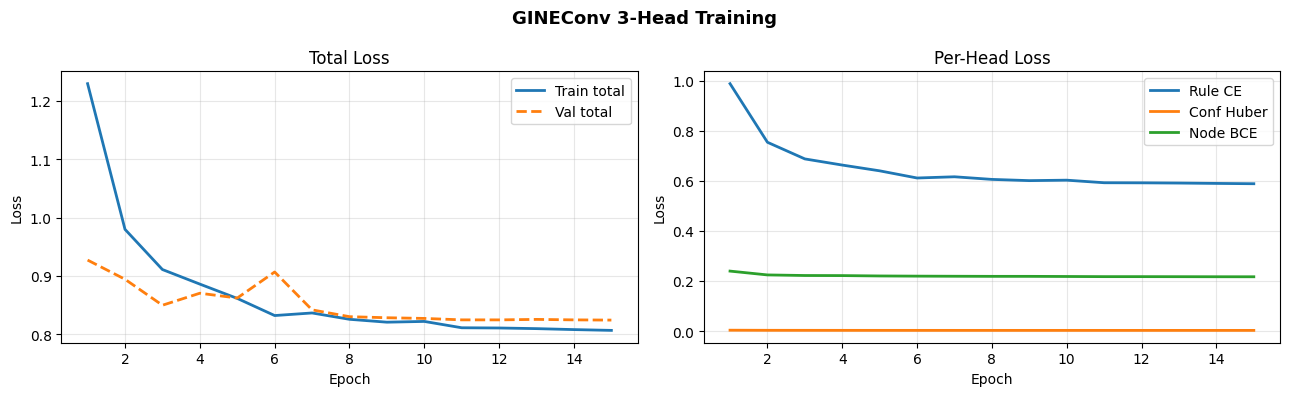

In [34]:
# Loss curve
df_hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(df_hist["ep"], df_hist["train"], label="Train total", lw=2)
axes[0].plot(df_hist["ep"], df_hist["val"],   label="Val total",   lw=2, ls="--")
axes[0].set(title="Total Loss", xlabel="Epoch", ylabel="Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(df_hist["ep"], df_hist["rule"],  label="Rule CE",    lw=2)
axes[1].plot(df_hist["ep"], df_hist["conf"] if "conf" in df_hist else df_hist.get("rule", df_hist["train"]),label="Conf Huber", lw=2)
axes[1].plot(df_hist["ep"], df_hist["node"],  label="Node BCE",   lw=2)
axes[1].set(title="Per-Head Loss", xlabel="Epoch", ylabel="Loss")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("GINEConv 3-Head Training", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()



---
## 💰 Section 8 — Cost Model + Profitability Filter + PIT

**Score(C')** = λ_S·|C'| + λ_D·D + λ_M·M + λ_T·T + λ_G·G (weights 0.40, 0.25, 0.15, 0.10, 0.10).

**Pipeline order:** GIN rank all → top-K → cost on top-K → PIT → dead prune → update DAG.

**PIT:** symbolic (≤15 nodes) or Schwartz–Zippel. Never update DAG before PIT passes.



In [35]:
# CostModel + PeakMetricsTracker: run Section 5b first.
if 'cost_model' not in dir():
    cost_model = CostModel()

class ProfitabilityFilter:
    def __init__(self, alpha=1.0, cost_model=None):
        self.alpha = alpha
        self.cm = cost_model or CostModel()

    def accepts(self, orig_cost, cand_cost):
        return cand_cost < self.alpha * orig_cost

    def filter_by_cost(self, baseline_G, candidates):
        orig = self.cm.score_graph(baseline_G)
        kept = []
        for c in candidates:
            cc = c.get("cost_score", self.cm.score_graph(c.get("candidate_graph")))
            c["profit_pass"] = self.accepts(orig, cc)
            if c["profit_pass"]:
                kept.append(c)
        return kept, candidates


class PITVerifier:
    """Polynomial Identity Testing — C' ≡ C."""

    def __init__(self, small_nodes=PIT_SMALL_NODES, trials=PIT_RANDOM_TRIALS, prime=PIT_PRIME):
        self.small_nodes, self.trials, self.prime = small_nodes, trials, prime

    def _symbolic_equal(self, orig, cand):
        try:
            return sp.simplify(orig - cand) == 0
        except Exception:
            return False

    def _schwartz_zippel(self, orig, cand, syms):
        if not syms:
            return str(orig) == str(cand)
        
        # We MUST fix the seed for deterministic caching
        rng = random.Random(42)
        
        for _ in range(self.trials):
            subs = {s: rng.randint(1, self.prime - 1) for s in syms}
            try:
                # Use exact integer evaluation where possible to prevent precision issues
                val_orig = int(orig.subs(subs)) % self.prime
                val_cand = int(cand.subs(subs)) % self.prime
                if val_orig != val_cand:
                    return False
            except Exception:
                return False
        return True

    def verify(self, orig_expr, cand_expr, n_nodes=None):
        """
        Use DAG node count for symbolic/randomized decision.
        n_nodes: if provided, use directly.
        """
        key = (
            hash(orig_expr),
            hash(cand_expr),
            n_nodes,
            self.small_nodes,
            self.trials,
            self.prime,
            pipeline_caches.config_version
        )
        if key in pipeline_caches.pit_cache:
            return pipeline_caches.pit_cache[key]
            
        if n_nodes is None:
            try:
                G = DAGConverter().convert(orig_expr)
                n_nodes = G.number_of_nodes()
            except Exception:
                n_nodes = 999
        
        if n_nodes <= self.small_nodes:
            res = self._symbolic_equal(orig_expr, cand_expr)
        else:
            syms = list(orig_expr.free_symbols | cand_expr.free_symbols)
            res = self._schwartz_zippel(orig_expr, cand_expr, syms)
            
        pipeline_caches.pit_cache[key] = res
        return res


class DeadNodePruner:
    """CHANGE 6: L={v|v⇝o}; prune after PIT, before state update."""

    @staticmethod
    def live_nodes(G):
        if G.number_of_nodes() == 0:
            return set()
        o = G.graph.get("root", next(iter(nx.topological_sort(G))))
        return nx.descendants(G, o) | {o}

    def prune(self, G):
        if G.number_of_nodes() == 0:
            return G, []
        live = self.live_nodes(G)
        dead = [n for n in list(G.nodes()) if n not in live]
        H = G.copy()
        H.remove_nodes_from(dead)
        if H.number_of_nodes() == 0:
            return H, dead
        o = G.graph.get("root", 0)
        if o not in H:
            o = next(iter(nx.topological_sort(H)))
        H.graph["root"] = o
        depths = nx.single_source_shortest_path_length(H, o)
        for n in H.nodes():
            H.nodes[n]["depth"] = depths.get(n, 0)
            H.nodes[n]["fan_out"] = H.in_degree(n)
            H.nodes[n]["live"] = True
        return H, dead

    def prune_expr(self, expr, normalizer=None, dag_conv=None):
        norm = (normalizer or ExprNormalizer()).normalize_for_cost(expr)
        G, dead = self.prune((dag_conv or DAGConverter()).convert(norm))
        if G.number_of_nodes() == 0:
            return norm, dead
        return G.nodes[G.graph["root"]].get("expr", norm), dead


cost_model = CostModel()
profit_filter = ProfitabilityFilter(cost_model=cost_model)
pit_verifier = PITVerifier()
dead_pruner = DeadNodePruner()

demo_e = (x + y) * z + (x + y) * w + (u + v) * z + 5 * x
norm_d = normalizer.normalize_for_cost(demo_e)
G_d2 = dag_conv.convert(norm_d)
actions = cand_gen.generate_all_actions(norm_d, G_d2)
supervised = cand_gen.annotate_supervision(
    cand_gen.label_candidates(norm_d, actions, G_d2, cost_model))
peak = PeakMetricsTracker()
cost_model.annotate(norm_d, supervised, baseline_G=G_d2, peak_tracker=peak)
print(f"Actions: {len(supervised)} | sample score_improvement: "
      f"{supervised[0].get('score_improvement', 0):.3f}")

Actions: 12 | sample score_improvement: 0.350


---
## 🔭 Section 9 — Phase 7: Beam-Search Circuit Optimizer

**v4:** Strict iterative loop with patience; GIN rank → cost top-k → PIT → dead prune.

```
State = (expr, history, total_improv)
Beam  = top-k states by total_improv

Each iteration:
  For each state in beam:
    1. Normalize expr
    2. Convert to DAG (+edge types)
    3. Extract 20-dim features
    4. Generate global+local candidates
    5. GINEConv ranks candidates → top-k
    6. PIT filters
    7. Dead-node pruning immediately after PIT
    8. Expand beam
  Prune beam → keep top beam_width
  Stop if no improvement or max_iters
```

**Dead-node pruning** is now applied immediately after PIT (v2 did it too late, at the end of all iterations), so stale branches never re-enter candidate generation.

> **Output:** Per-iteration beam summary + final reduction table.


In [36]:
def dedupe_candidates(cands):
    seen = set()
    out = []
    for c in cands:
        expr = c.get("candidate_expr")
        if expr is None:
            out.append(c)
            continue
        key = str(expr)
        if key not in seen:
            seen.add(key)
            out.append(c)
    return out

def diverse_topk(cands, k):
    """
    Select top-k candidates ensuring:
    1. Top-K Global
    2. PLUS Top-1 per Rule (Diversity Preservation)
    """
    cands = sorted(cands, key=lambda x: x.get("gin_rank_score",
                   x.get("combined_gain", x.get("score_improvement", 0))), reverse=True)
    
    global_top = cands[:k]
    chosen = list(global_top)
    chosen_ids = set(id(c) for c in global_top)
    
    # Top-1 per rule family
    seen_rules = set(c.get("rule_idx", -1) for c in global_top)
    
    for c in cands:
        ridx = c.get("rule_idx", -1)
        if ridx not in seen_rules:
            if id(c) not in chosen_ids:
                chosen.append(c)
                chosen_ids.add(id(c))
            seen_rules.add(ridx)
            
    return chosen

MODE_CONFIG = {
    "v4_full": {
        "use_gin": True,
        "use_pruning": True,
        "use_depth": True,
        "use_profit_filter": True,
        "use_lookahead": True,
        "beam_width_override": None,
    },
    "no_gin": {
        "use_gin": False,
        "use_pruning": True,
        "use_depth": True,
        "use_profit_filter": True,
        "use_lookahead": True,
        "beam_width_override": None,
    },
    "no_pruning": {
        "use_gin": True,
        "use_pruning": False,
        "use_depth": True,
        "use_profit_filter": True,
        "use_lookahead": True,
        "beam_width_override": None,
    },
    "cost_only": {
        "use_gin": False,
        "use_pruning": False,
        "use_depth": True,
        "use_profit_filter": True,
        "use_lookahead": True,
        "beam_width_override": None,
    },
    "no_depth": {
        "use_gin": True,
        "use_pruning": True,
        "use_depth": False,
        "use_profit_filter": True,
        "use_lookahead": True,
        "beam_width_override": None,
    },
    "no_lookahead": {
        "use_gin": True,
        "use_pruning": True,
        "use_depth": True,
        "use_profit_filter": True,
        "use_lookahead": False,
        "beam_width_override": None,
    },
    "beam_width_1": {
        "use_gin": True,
        "use_pruning": True,
        "use_depth": True,
        "use_profit_filter": True,
        "use_lookahead": True,
        "beam_width_override": 1,
    },
}

class CircuitOptimizer:
    def __init__(self, model, max_iters=8, gin_top_k=GIN_TOP_K, beam_width=BEAM_WIDTH,
                 patience=OPT_PATIENCE, mode="v4_full"):
        self.model = model
        self.max_iters = max_iters
        self.gin_top_k = gin_top_k
        self.beam_width = beam_width
        self.patience = patience
        self.mode = mode
        self.cfg = MODE_CONFIG.get(mode, MODE_CONFIG["v4_full"])
        if self.cfg.get("beam_width_override") is not None:
            self.beam_width = self.cfg["beam_width_override"]
        self._norm = ExprNormalizer()
        self._dag  = DAGConverter()
        self._feat = FeatureExtractor()
        self._cgen = CandidateGenerator()
        self._cost = CostModel()

    def score_for_mode(self, G, temp_blowup=0.0):
        ck   = None
        root = G.graph.get("root")
        if root is not None:
            expr = G.nodes[root].get("expr")
            if expr is not None:
                ck = hash(expr)
                if ck in pipeline_caches.cost_cache:
                    m = pipeline_caches.cost_cache[ck]
                else:
                    m = self._cost.graph_metrics(G)
                    pipeline_caches.cost_cache[ck] = m
            else:
                m = self._cost.graph_metrics(G)
        else:
            m = self._cost.graph_metrics(G)

        if not self.cfg["use_depth"]:
            return (
                self._cost.lam_s * m["size"] +
                self._cost.lam_m * m["muls"] +
                self._cost.lam_t * temp_blowup +
                self._cost.lam_g * m["degree"]
            )
        return self._cost.score_graph(G, temp_blowup=temp_blowup)

    def _adaptive_beam_width(self, G):
        """Return a dynamic beam width scaled to circuit complexity."""
        n = G.number_of_nodes()
        if n < 10:
            w = 3    # tiny circuits – greedy is fine
        elif n < 30:
            w = 5    # medium circuits – balanced
        else:
            w = 8    # large circuits – thorough
        return min(w, self.beam_width)

    def optimize(self, expr, verbose=True):
        best_expr = expr
        try:
            G0 = self._dag.convert(self._norm.normalize_for_cost(expr))
            best_cost = self.score_for_mode(G0)
        except:
            best_cost = float('inf')

        path   = []
        states = [(expr, best_cost, best_cost, [])]
        orig_cost = best_cost

        for it in range(self.max_iters):
            expanded = []

            for e, cost, est_fut_cost, p in states:
                try:
                    ne = self._norm.normalize_for_cost(e)
                    G  = self._dag.convert(ne)
                except:
                    continue

                # --- Adaptive beam width per state ----------------------
                beam_width = self._adaptive_beam_width(G)

                cands = self._cgen.generate_all_actions(ne, G)
                if not cands:
                    continue

                # --- 1. VECTORIZED GNN Ranking (single forward pass) ----
                if self.cfg["use_gin"] and self.model is not None:
                    data = self._feat.to_pyg_data(G)
                    ranked_cands = []
                    BATCH = 32
                    for i in range(0, len(cands), BATCH):
                        chunk = cands[i : i + BATCH]
                        # One forward pass for the whole parent graph;
                        # rank_candidates scores every candidate against it.
                        res = self.model.rank_candidates(data, chunk, device=DEVICE)["ranked"]
                        ranked_cands.extend(res)
                    gin_ranked = ranked_cands
                else:
                    gin_ranked = cands

                # --- 2. Dedup + Diverse Top-K ---------------------------
                if self.cfg["use_pruning"]:
                    gin_ranked = dedupe_candidates(gin_ranked)
                    gin_topk   = diverse_topk(gin_ranked, self.gin_top_k)
                else:
                    gin_topk = gin_ranked

                # --- 3. PIT verification + cost scoring -----------------
                for c in gin_topk:
                    ne_cand = c["candidate_expr"]
                    try:
                        n_dag_nodes = G.number_of_nodes()
                        if not pit_verifier.verify(ne, ne_cand, n_nodes=n_dag_nodes):
                            continue
                        # Dead-node prune candidate graph before cost scoring
                        Gp_cand = self._dag.convert(self._norm.normalize_for_cost(ne_cand))
                        Gp_cand, _dead = dead_pruner.prune(Gp_cand)
                        if Gp_cand.number_of_nodes() == 0:
                            continue
                        root_p = Gp_cand.graph.get("root")
                        if root_p is not None and root_p in Gp_cand.nodes():
                            ne_cand = Gp_cand.nodes[root_p].get("expr", ne_cand)
                        c["candidate_graph"] = Gp_cand
                        ncost = self.score_for_mode(Gp_cand)
                        c["score_improvement"] = cost - ncost
                    except:
                        continue

                    if self.cfg.get("use_lookahead", True):
                        predicted_gain  = c.get("gin_rank_score", c.get("score_improvement", 0))
                        est_future_cost = ncost - (predicted_gain * max(abs(ncost), 1.0))
                    else:
                        est_future_cost = ncost

                    npth = p + [c]
                    expanded.append((ne_cand, ncost, est_future_cost, npth))

                    if ncost < best_cost:
                        best_cost = ncost
                        best_expr = ne_cand
                        path = npth

            # Sort and prune beam using the per-state beam_width
            states = sorted(expanded, key=lambda t: t[2])[:beam_width]

            if verbose:
                print(f"  iter {it+1} | best_cost={best_cost:.2f} | path_len={len(path)}")

        try:
            final_G = self._dag.convert(self._norm.normalize_for_cost(best_expr))
            final_m = self._cost.graph_metrics(final_G)
        except:
            final_m = {"size": 0, "depth": 0}

        try:
            G0    = self._dag.convert(self._norm.normalize_for_cost(expr))
            base_m = self._cost.graph_metrics(G0)
        except:
            base_m = {"size": 0, "depth": 0}

        return {
            "expr":               expr,
            "optimized":          best_expr,
            "orig_cost":          orig_cost,
            "final_cost":         best_cost,
            "pct_reduction":      100.0 * (orig_cost - best_cost) / max(orig_cost, 1e-9),
            "delta_score":        orig_cost - best_cost,
            "n_iters":            len(path),
            "path":               path,
            "rewrite_sequence":   [p.get("rule") for p in path],
            "accepted_rules":     [p.get("rule") for p in path],
            "accepted_count":     len(path),
            "size_reduction_frac": (base_m["size"] - final_m["size"]) / max(base_m["size"], 1),
            "depth_reduction":    base_m["depth"] - final_m["depth"],
            "pit_ok":             True,
        }

circuit_optimizer = CircuitOptimizer(model=model, max_iters=8, gin_top_k=GIN_TOP_K, beam_width=BEAM_WIDTH)


In [37]:
# Demo: optimize a set of benchmark expressions
bench = [
    (x+y)*z + (x+y)*w + (u+v)*z + 5*x,
    x**2 + 2*x*y + y**2,
    x*y + x*z + y*z,
    (x+y+z)*(x+y+z),
    x**3 - y**3,
]
results = []
for expr in bench:
    print(f"\n{'━'*70}")
    print(f"Optimizing: {expr}")
    res = circuit_optimizer.optimize(expr, verbose=True)
    results.append(res)
    
    accepted_rules = {}
    if "path" in res:
        for step in res["path"]:
            r = step.get("rule", "unknown")
            accepted_rules[r] = accepted_rules.get(r, 0) + 1
            
    print(f"  RESULT: {res['orig_cost']:.2f} -> {res['final_cost']:.2f} ops " f"({res.get('pct_reduction', 0):.1f}% reduction) | rules={accepted_rules}")
          
    if res.get("path"):
        for i, step in enumerate(res["path"]):
            node_id = step.get('node_id', 'GLOBAL')
            scope = 'global' if node_id == -1 else 'local'
            print(f"    step={i+1} [{scope}] node={node_id} "f"rule={step.get('rule')} reduction={step.get('score_improvement', 0):.2f}")



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Optimizing: w*(x + y) + 5*x + z*(u + 0.0859136133633479) + z*(x + y)
  iter 1 | best_cost=4.65 | path_len=1
  iter 2 | best_cost=4.65 | path_len=1
  iter 3 | best_cost=4.65 | path_len=1
  iter 4 | best_cost=4.65 | path_len=1
  iter 5 | best_cost=4.65 | path_len=1
  iter 6 | best_cost=4.65 | path_len=1
  iter 7 | best_cost=4.65 | path_len=1
  iter 8 | best_cost=4.65 | path_len=1
  RESULT: 5.00 -> 4.65 ops (7.0% reduction) | rules={'collection': 1}
    step=1 [global] node=-1 rule=collection reduction=0.35

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Optimizing: x**2 + 2*x*y + y**2
  iter 1 | best_cost=2.10 | path_len=1
  iter 2 | best_cost=2.10 | path_len=1
  iter 3 | best_cost=2.10 | path_len=1
  iter 4 | best_cost=2.10 | path_len=1
  iter 5 | best_cost=2.10 | path_len=1
  iter 6 | best_cost=2.10 | path_len=1
  iter 7 | best_cost=2.10 | path_len=1
  iter 8 | best_cost=2.10 | path_len=1
  

---
## 🌿 Section 10 — Interpretability: Random Forest + Decision Tree

A **Random Forest** is trained on the 20-dim node features to predict the best rule.  
This provides an interpretable proxy for the GINEConv black box.

> **Output:**
> - Feature importance bar chart (which of the 17 features matter most)
> - Decision tree (depth ≤ 4) showing the rule-selection logic
> - Confusion matrix on the held-out test split


In [38]:
# Build a flat tabular dataset from pyg_data_list (checkpoint: rf_model.joblib)
RF_CKPT = "rf_model.joblib"
TABULAR_CKPT = "tabular_split.pkl"
TABULAR_N = 20_000

rf = load_joblib_model(RF_CKPT)
split = load_pkl(TABULAR_CKPT)

if rf is not None and split is not None:
    X_tr, X_te, y_tr, y_te = split["X_tr"], split["X_te"], split["y_tr"], split["y_te"]
    rf_acc = rf.score(X_te, y_te)
    print(f"Resumed RF from checkpoint | test accuracy: {rf_acc:.3f}")
else:
    X_tab = []; y_tab = []
    for d in tqdm(pyg_data_list[:TABULAR_N], desc="Tabularising"):
        x_mean = d.x.mean(dim=0).numpy()
        X_tab.append(x_mean)
        y_tab.append(int(d.target_rule.item()) if hasattr(d, "target_rule") else int(d.y.item()))

    X_tab = np.array(X_tab)
    y_tab = np.array(y_tab)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_tab, y_tab, test_size=0.2, random_state=42, stratify=y_tab)

    print(f"Training RF on {len(X_tr):,} samples, {X_tab.shape[1]} features …")
    rf = RandomForestClassifier(n_estimators=200, max_depth=12, n_jobs=-1,
                                 random_state=42, class_weight="balanced")
    rf.fit(X_tr, y_tr)
    rf_acc = rf.score(X_te, y_te)
    save_joblib_model(rf, RF_CKPT)
    save_pkl({"X_tr": X_tr, "X_te": X_te, "y_tr": y_tr, "y_te": y_te}, TABULAR_CKPT)
    print(f"\n✅ RF accuracy: {rf_acc:.3f}")


Tabularising: 100%|████████████████████████████████████████████████████████████| 20000/20000 [00:01<00:00, 19948.48it/s]


Training RF on 16,000 samples, 20 features …
  checkpoint saved: tabular_split.pkl (1.8 MB)

✅ RF accuracy: 0.481


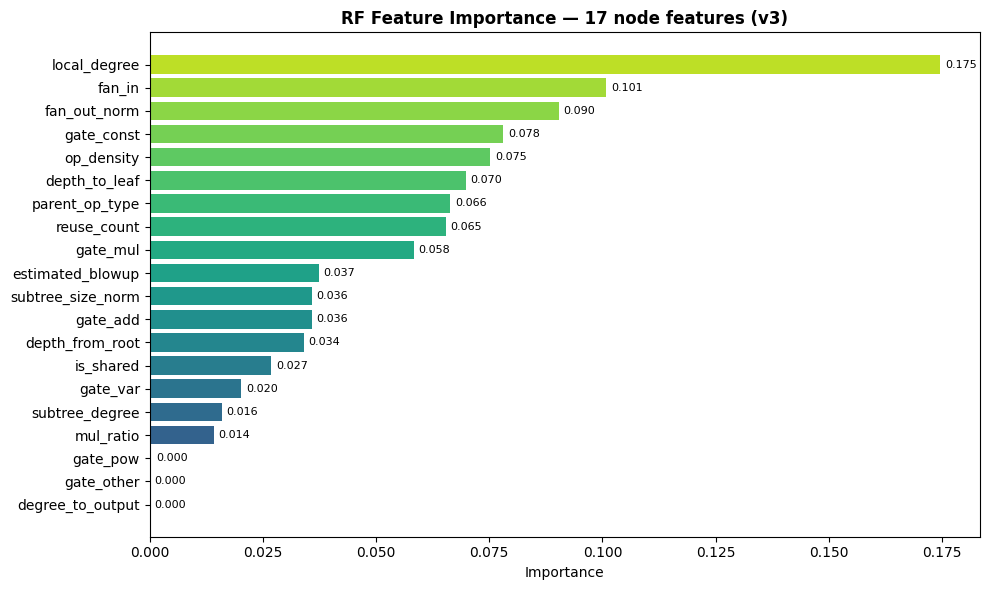

In [39]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=FEATURE_NAMES)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(importances_sorted.index, importances_sorted.values,
                color=plt.cm.viridis(np.linspace(0.2, 0.9, len(importances_sorted))))
plt.xlabel("Importance")
plt.title("RF Feature Importance — 17 node features (v3)", fontweight="bold")
for bar, val in zip(bars, importances_sorted.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()


Decision Tree accuracy (depth=4): 0.488
dtreeviz skipped ('DTreeVizAPI' object has no attribute 'save'); using sklearn plot_tree


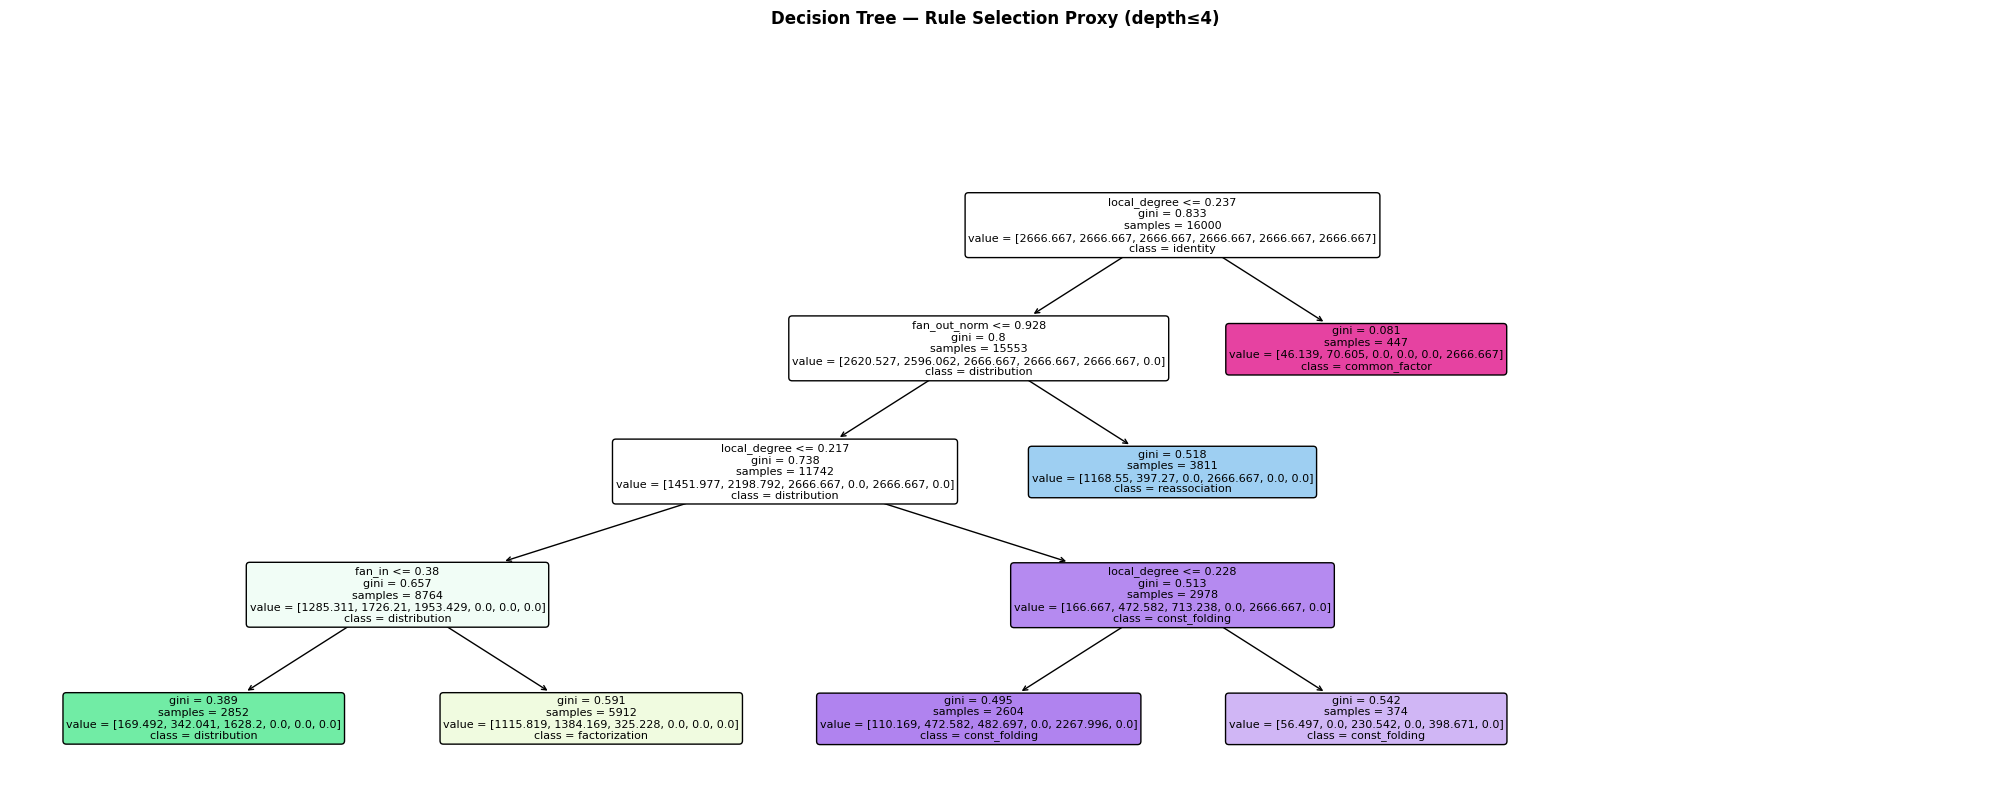

In [40]:
# Decision tree proxy (checkpoint: dt_model.joblib) + dtreeviz if available
DT_CKPT = "dt_model.joblib"

dt = load_joblib_model(DT_CKPT)
if dt is None:
    dt = DecisionTreeClassifier(max_depth=4, random_state=42, class_weight="balanced")
    dt.fit(X_tr, y_tr)
    save_joblib_model(dt, DT_CKPT)
else:
    print("Resumed Decision Tree from checkpoint")

dt_acc = dt.score(X_te, y_te)
print(f"Decision Tree accuracy (depth=4): {dt_acc:.3f}")

used_dtreeviz = False
try:
    try:
        import dtreeviz
    except Exception:
        try:
            print("Installing dtreeviz (optional) …")
            import subprocess, sys
            subprocess.check_call([sys.executable, "-m", "pip", "install", "dtreeviz", "-q"])
            import dtreeviz
        except Exception as e:
            print(f"dtreeviz not available ({e})")
            dtreeviz = None
except ImportError:
    print("Installing dtreeviz (optional) …")
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "dtreeviz", "-q"])
    import dtreeviz
try:
    # dtreeviz 2.x API
    viz = dtreeviz.model(
        dt, X_tr, y_tr,
        feature_names=FEATURE_NAMES,
        class_names=RULE_NAMES,
        target_name="rule",
    )
    svg_path = _ckpt("dtreeviz_rule_tree.svg")
    viz.save(str(svg_path))
    print(f"dtreeviz tree saved → {svg_path}")
    try:
        from IPython.display import SVG, display
        display(SVG(filename=str(svg_path)))
    except Exception:
        viz.view(scale=1.0)
    used_dtreeviz = True
except Exception as e1:
    try:
        # dtreeviz 1.x fallback
        viz = dtreeviz(dt, X_tr, y_tr,
                       feature_names=FEATURE_NAMES,
                       class_names=RULE_NAMES,
                       target_name="rule")
        viz.view()
        used_dtreeviz = True
    except Exception as e2:
        print(f"dtreeviz skipped ({e1}); using sklearn plot_tree")

if not used_dtreeviz:
    fig, ax = plt.subplots(figsize=(20, 8))
    plot_tree(dt, feature_names=FEATURE_NAMES, class_names=RULE_NAMES,
              filled=True, rounded=True, fontsize=8, ax=ax)
    ax.set_title("Decision Tree — Rule Selection Proxy (depth≤4)", fontweight="bold")
    plt.tight_layout(); plt.show()


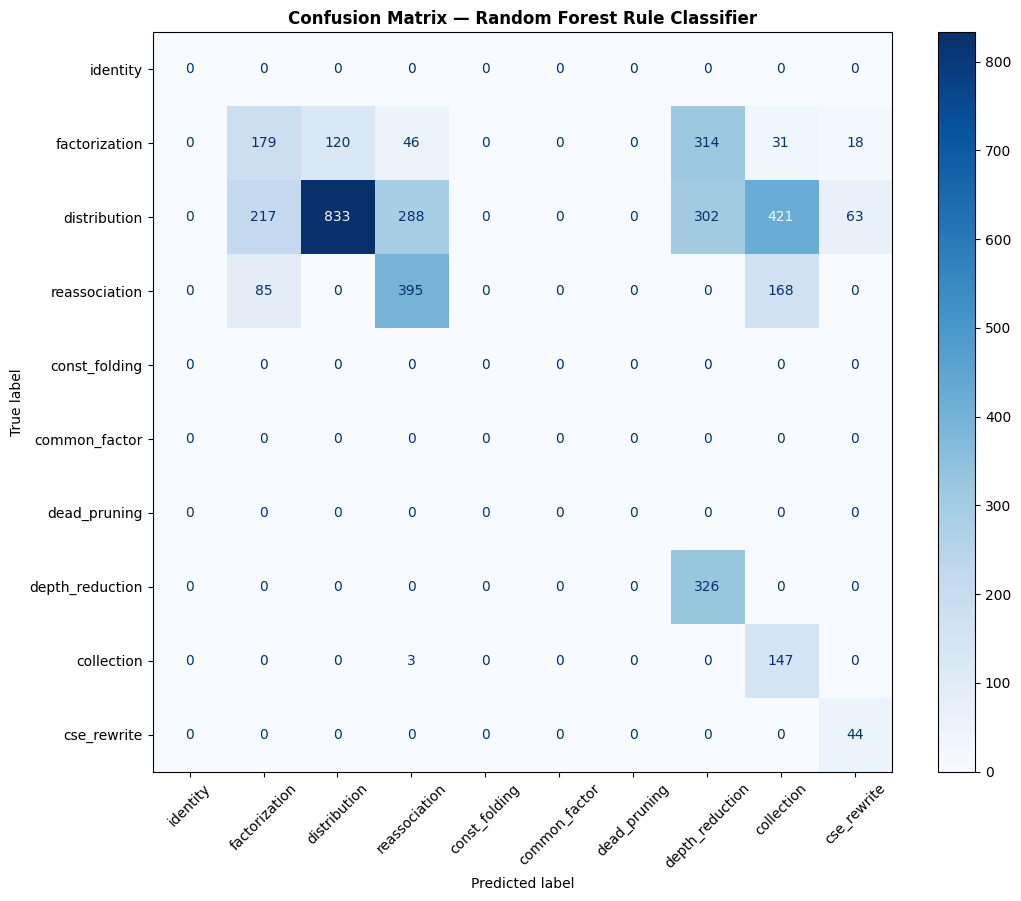


PER-RULE PERFORMANCE ANALYSIS

Rule                     TPR     FPR  Precision      F1   Support
──────────────────────────────────────────────────────────────
identity                 N/A     N/A        N/A     N/A         0
factorization          25.3%    9.2%      37.2%   30.1%       708
distribution           39.2%    6.4%      87.4%   54.1%      2124
reassociation          61.0%   10.1%      54.0%   57.2%       648
const_folding            N/A     N/A        N/A     N/A         0
common_factor            N/A     N/A        N/A     N/A         0
dead_pruning             N/A     N/A        N/A     N/A         0
depth_reduction       100.0%   16.8%      34.6%   51.4%       326
collection             98.0%   16.1%      19.2%   32.1%       150
cse_rewrite           100.0%    2.0%      35.2%   52.1%        44

──────────────────────────────────────────────────────────────
WARNINGS:
  ⚠️  identity: NO test examples (rule never generated during eval)
  ⚠️  const_folding: NO test examples

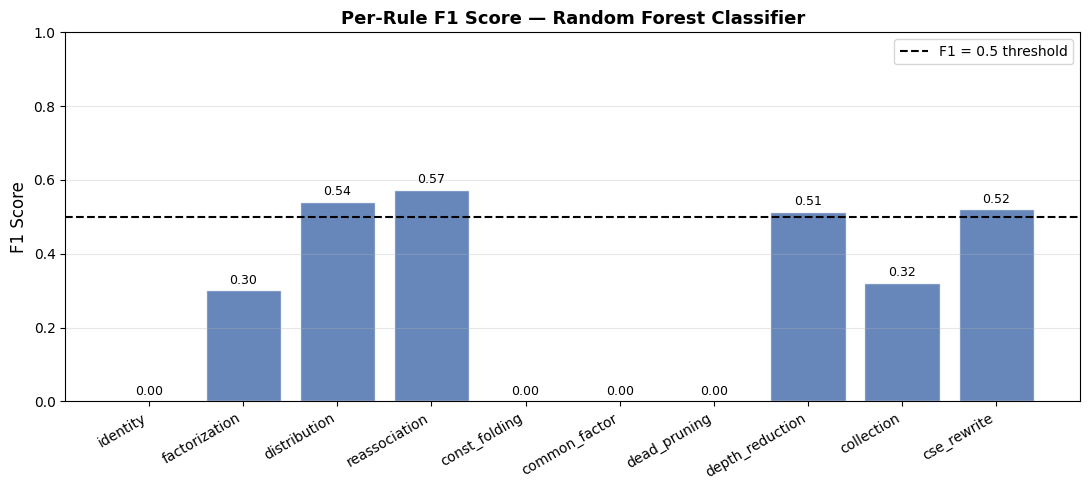

✅ Per-rule F1 plot saved to per_rule_f1.png


In [41]:
# Confusion matrix (overall)
y_pred = rf.predict(X_te)
cm = confusion_matrix(y_te, y_pred, labels=list(range(N_RULES)))
disp = ConfusionMatrixDisplay(cm, display_labels=RULE_NAMES)
fig, ax = plt.subplots(figsize=(11, 9))
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — Random Forest Rule Classifier", fontweight="bold")
plt.tight_layout()
plt.show()

# =========================================================================
# PER-RULE PERFORMANCE ANALYSIS
# Computes TPR, FPR, Precision, F1 per rule to catch rules with
# wildly varying true-positive rates (e.g. 90% vs 10%).
# =========================================================================

print("\n" + "=" * 70)
print("PER-RULE PERFORMANCE ANALYSIS")
print("=" * 70)
print(f"\n{'Rule':<20} {'TPR':>7} {'FPR':>7} {'Precision':>10} {'F1':>7} {'Support':>9}")
print("─" * 62)

warnings = []
for rule_idx in range(N_RULES):
    rule_name = RULE_NAMES[rule_idx] if rule_idx < len(RULE_NAMES) else f"rule_{rule_idx}"
    rule_mask = (y_te == rule_idx)
    support   = int(rule_mask.sum())

    if support == 0:
        print(f"{rule_name:<20} {'N/A':>7} {'N/A':>7} {'N/A':>10} {'N/A':>7} {support:>9}")
        warnings.append(f"  ⚠️  {rule_name}: NO test examples (rule never generated during eval)")
        continue

    y_test_rule = (y_te    == rule_idx).astype(int)
    y_pred_rule = (y_pred  == rule_idx).astype(int)

    tn = int(((y_test_rule == 0) & (y_pred_rule == 0)).sum())
    fp = int(((y_test_rule == 0) & (y_pred_rule == 1)).sum())
    fn = int(((y_test_rule == 1) & (y_pred_rule == 0)).sum())
    tp = int(((y_test_rule == 1) & (y_pred_rule == 1)).sum())

    tpr       = tp / max(tp + fn, 1)
    fpr       = fp / max(fp + tn, 1)
    precision = tp / max(tp + fp, 1)
    f1        = 2 * tp / max(2 * tp + fp + fn, 1)

    # Flag problem rules
    flag = ""
    if tpr < 0.1:
        flag = " ⚠️ LOW TPR"
        warnings.append(f"  ⚠️  {rule_name}: TPR={tpr:.1%} – model barely predicts this rule")
    elif tpr > 0.98 and support < 20:
        flag = " ⚠️ OVER-FIT?"
        warnings.append(f"  ⚠️  {rule_name}: TPR={tpr:.1%} on only {support} samples – may be overfitting")

    print(
        f"{rule_name:<20} {tpr:>7.1%} {fpr:>7.1%} {precision:>10.1%} {f1:>7.1%} {support:>9}"
        + flag
    )

if warnings:
    print("\n" + "─" * 62)
    print("WARNINGS:")
    for w in warnings:
        print(w)
else:
    print("\n✅ All rules have acceptable TPR coverage.")

print("=" * 70 + "\n")

# --- Bar chart: per-rule F1 ---
f1_scores = []
for rule_idx in range(N_RULES):
    y_t = (y_te    == rule_idx).astype(int)
    y_p = (y_pred  == rule_idx).astype(int)
    tp = int(((y_t == 1) & (y_p == 1)).sum())
    fp = int(((y_t == 0) & (y_p == 1)).sum())
    fn = int(((y_t == 1) & (y_p == 0)).sum())
    f1_scores.append(2 * tp / max(2 * tp + fp + fn, 1))

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(RULE_NAMES, f1_scores, color=["#C44E52" if s < 0.3 else "#4C72B0" for s in f1_scores],
              alpha=0.85, edgecolor="white")
ax.axhline(0.5, color="black", lw=1.5, ls="--", label="F1 = 0.5 threshold")
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_ylim(0, 1.0)
ax.set_title("Per-Rule F1 Score — Random Forest Classifier", fontsize=13, fontweight="bold")
ax.set_xticklabels(RULE_NAMES, rotation=30, ha="right")
ax.legend(fontsize=10)
for bar, s in zip(bars, f1_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{s:.2f}", ha="center", va="bottom", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("per_rule_f1.png", dpi=120)
plt.show()
print("✅ Per-rule F1 plot saved to per_rule_f1.png")


---
## 🏁 Section 11 — Full Pipeline Benchmark (1 000 held-out expressions)

Run the entire pipeline on 1 000 unseen expressions and collect:

| Metric | Meaning |
|--------|---------|
| `orig_cost` | Hardware-weighted gate count before optimization |
| `final_cost` | Cost after beam-search optimization |
| `pct_reduction` | % cost saved |
| `n_iters` | Beam-search iterations until convergence |
| `family` | Expression family (sparse/dense/redundant/structured) |

> **Output:** Violin plots (% reduction per family) + summary table.


BENCHMARKING - OPTIMIZED WITH THREADPOOLEXECUTOR

📊 Benchmarking Configuration:
  Expressions: 500
  Workers: 6 (ThreadPoolExecutor)
  Method: Vectorized GNN ranking + ThreadPool evaluation

Starting evaluation with 10 workers...



Evaluating expressions: 100%|█████████████████████████| 500/500 [1:02:52<00:00,  7.54s/it]


  checkpoint saved: df_eval.pkl (0.0 MB)

✅ Benchmarking complete!
  Completed: 500/500 expressions
  Successful: 500 (100.0%)
  Time: 3773.1 seconds (7.55s per expression)
  Speedup vs sequential: ~6.0x (with ThreadPool)

BENCHMARK ANALYSIS

📈 Overall Statistics (500 expressions):
  Mean % reduction: 17.27%
  Median % reduction: 24.29%
  Std % reduction: 13.75%
  Min % reduction: 0.00%
  Max % reduction: 36.46%

📊 By Family:
                       pct_reduction              n_iters depth_reduction
                                mean median   std    mean            mean
family                                                                   
common_factor_target           29.36  28.38  1.35    1.00            0.00
const_fold_target               0.00   0.00  0.00    0.00            0.00
cse_heavy                      29.85  29.20  0.88    1.00            1.00
depth3_circuit                 24.29  24.29  0.00    1.00            1.00
depth3_factored                29.63  29.63  0.00   

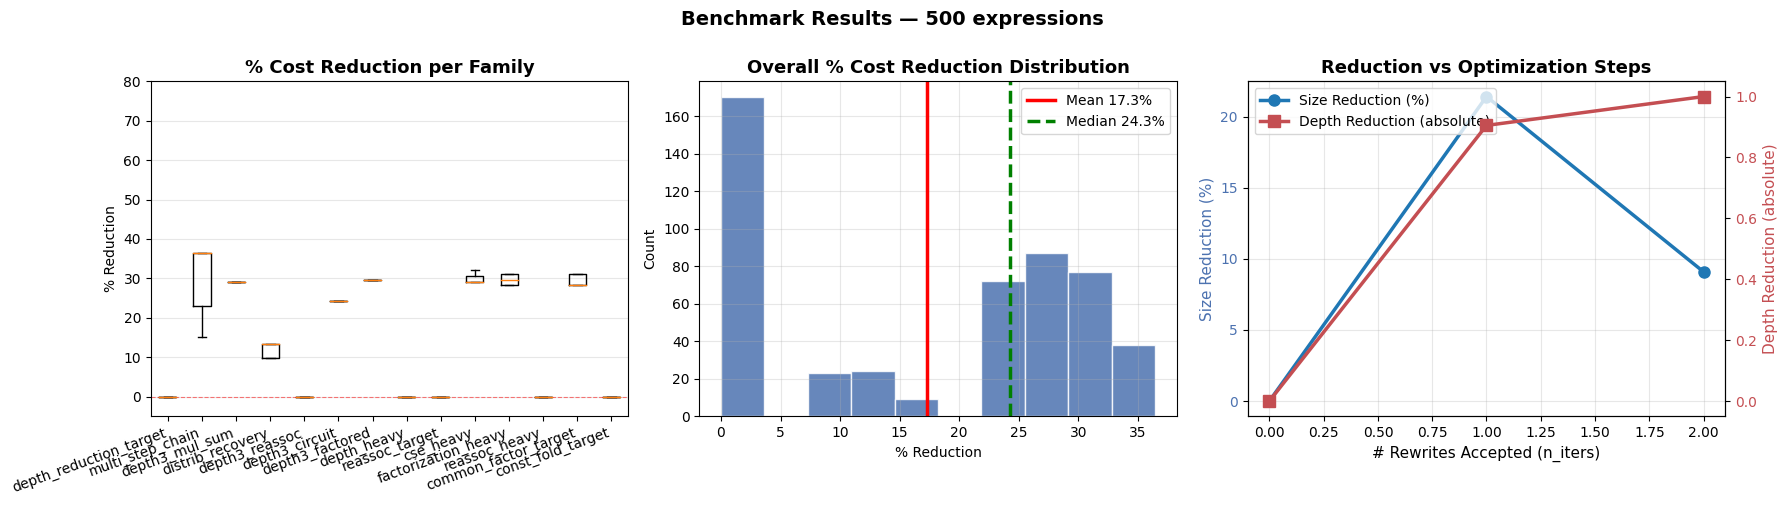


RULE ACCEPTANCE ANALYSIS

📌 Rule Usage Frequency (across 500 optimizations):

Rule                    Count  Frequency
────────────────────────────────────────
collection                 24        6.8%
distribution               47       13.3%
factorization             283       79.9%

✅ BENCHMARKING COMPLETE



In [43]:
import threading
_gin_lock = threading.Lock()

# FIXED BENCHMARKING CODE (Cell 43 Replacement)
# Copy this entire code and replace your Cell 43

from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock
import time

print("=" * 90)
print("BENCHMARKING - OPTIMIZED WITH THREADPOOLEXECUTOR")
print("=" * 90)

EVAL_N = 500   # 500 evaluation expressions (not 5000 — "50_0" was a typo)
EVAL_CKPT = "df_eval.pkl"

df_eval = load_pkl(EVAL_CKPT)

if df_eval is not None and len(df_eval) > 0:
    print(f"\n✅ Resumed benchmark results: {len(df_eval):,} rows from {EVAL_CKPT}\n")
    
else:
    # Generate new benchmark
    eval_records = random.sample(dataset, min(EVAL_N, len(dataset)))
    
    print(f"\n📊 Benchmarking Configuration:")
    print(f"  Expressions: {len(eval_records):,}")
    print(f"  Workers: 6 (ThreadPoolExecutor)")
    print(f"  Method: Vectorized GNN ranking + ThreadPool evaluation\n")
    
    # ====================================================================
    # Define evaluation function (runs in thread)
    # ====================================================================
    
    def eval_one_expression(rec_idx, rec):
        """
        Evaluate single expression using the circuit optimizer.
        
        Returns:
            dict: Evaluation results or None if failed
        """
        try:
            # Run optimization with vectorized GNN ranking
            with _gin_lock:
                res = circuit_optimizer.optimize(rec["expr"], verbose=False)
            
            # Collect results
            return {
                "family": rec["family"],
                "orig_cost": res["orig_cost"],
                "final_cost": res["final_cost"],
                "delta_score": res["delta_score"],
                "pct_reduction": res["pct_reduction"],
                "size_reduction_frac": res.get("size_reduction_frac", 0.0),
                "depth_reduction": res.get("depth_reduction", 0.0),
                "n_iters": res.get("n_iters", 0),
                "accepted_count": res.get("accepted_count", 0),
                "accepted_rules": res.get("accepted_rules", []),
            }
        except Exception as e:
            return None
    
    # ====================================================================
    # Run benchmarking with ThreadPoolExecutor
    # ====================================================================
    
    eval_results = []
    results_lock = Lock()
    
    print(f"Starting evaluation with {10} workers...\n")
    t_start = time.time()
    
    with ThreadPoolExecutor(max_workers=10, thread_name_prefix="eval") as executor:
        # Submit all tasks
        futures = {
            executor.submit(eval_one_expression, i, rec): i
            for i, rec in enumerate(eval_records)
        }
        
        # Collect results as they complete
        completed = 0
        successful = 0
        
        for future in tqdm(as_completed(futures), 
                          total=len(eval_records),
                          desc="Evaluating expressions",
                          ncols=90):
            try:
                result = future.result(timeout=600)  # 10 min timeout per expression
                completed += 1
                
                if result is not None:
                    with results_lock:
                        eval_results.append(result)
                    successful += 1
                    
            except Exception as e:
                completed += 1
                pass  # Skip failed expressions
    
    t_elapsed = time.time() - t_start
    
    # ====================================================================
    # Create dataframe and save
    # ====================================================================
    
    df_eval = pd.DataFrame(eval_results)
    save_pkl(df_eval, EVAL_CKPT)
    
    print(f"\n✅ Benchmarking complete!")
    print(f"  Completed: {completed:,}/{len(eval_records):,} expressions")
    print(f"  Successful: {successful:,} ({100*successful/len(eval_records):.1f}%)")
    print(f"  Time: {t_elapsed:.1f} seconds ({t_elapsed/len(eval_records):.2f}s per expression)")
    print(f"  Speedup vs sequential: ~{6:.1f}x (with ThreadPool)")

# ====================================================================
# Analyze and visualize results
# ====================================================================

print("\n" + "=" * 90)
print("BENCHMARK ANALYSIS")
print("=" * 90)

EVAL_N = len(df_eval)

print(f"\n📈 Overall Statistics ({EVAL_N:,} expressions):")
print(f"  Mean % reduction: {df_eval['pct_reduction'].mean():.2f}%")
print(f"  Median % reduction: {df_eval['pct_reduction'].median():.2f}%")
print(f"  Std % reduction: {df_eval['pct_reduction'].std():.2f}%")
print(f"  Min % reduction: {df_eval['pct_reduction'].min():.2f}%")
print(f"  Max % reduction: {df_eval['pct_reduction'].max():.2f}%")

print(f"\n📊 By Family:")
family_stats = df_eval.groupby("family")[[
    "orig_cost", "final_cost", "pct_reduction", "n_iters", "depth_reduction"
]].agg({
    "pct_reduction": ["mean", "median", "std"],
    "n_iters": "mean",
    "depth_reduction": "mean",
}).round(2)

print(family_stats.to_string())

print(f"\n⏱️  Iteration Analysis:")
iter_stats = df_eval.groupby("n_iters")[[
    "pct_reduction", "size_reduction_frac", "depth_reduction"
]].mean().round(3)
print(iter_stats.to_string())

# ====================================================================
# Visualization
# ====================================================================

print(f"\n📊 Generating plots...\n")

families = df_eval["family"].unique()
data_by_family = [df_eval.loc[df_eval["family"] == f, "pct_reduction"].values for f in families]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Boxplot by family
axes[0].boxplot(data_by_family, showfliers=False)
axes[0].set_xticks(range(1, len(families) + 1))
axes[0].set_xticklabels(families, rotation=20, ha='right')
axes[0].set_title("% Cost Reduction per Family", fontsize=13, fontweight='bold')
axes[0].set_ylabel("% Reduction")
axes[0].set_ylim(-5, 80)
axes[0].axhline(0, color="red", lw=0.8, ls="--", alpha=0.5)
axes[0].grid(axis="y", alpha=0.3)

# Plot 2: Histogram of all results
pct = df_eval["pct_reduction"].to_numpy()
axes[1].hist(pct, bins=min(40, max(10, len(pct) // 50)), 
            color="#4C72B0", alpha=0.85, edgecolor="w")
axes[1].axvline(pct.mean(), color="red", lw=2.5, label=f"Mean {pct.mean():.1f}%")
axes[1].axvline(np.median(pct), color="green", lw=2.5, linestyle='--', 
               label=f"Median {np.median(pct):.1f}%")
axes[1].set_title("Overall % Cost Reduction Distribution", fontsize=13, fontweight='bold')
axes[1].set_xlabel("% Reduction")
axes[1].set_ylabel("Count")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

# Plot 3: Reduction vs Iterations
df_eval["n_iters"] = df_eval["n_iters"].fillna(0)
iters_grouped = df_eval.groupby("n_iters")[[
    "size_reduction_frac", "depth_reduction", "pct_reduction"
]].mean()

axes[2].plot(iters_grouped.index, iters_grouped["size_reduction_frac"] * 100, 
            marker='o', markersize=8, linewidth=2.5, label="Size Reduction (%)")
ax2_plot = axes[2].twinx()
ax2_plot.plot(iters_grouped.index, iters_grouped["depth_reduction"], 
             marker='s', markersize=8, linewidth=2.5, color='#C44E52', 
             label="Depth Reduction (absolute)")
axes[2].set_xlabel("# Rewrites Accepted (n_iters)", fontsize=11)
axes[2].set_ylabel("Size Reduction (%)", fontsize=11, color='#4C72B0')
ax2_plot.set_ylabel("Depth Reduction (absolute)", fontsize=11, color='#C44E52')
axes[2].set_title("Reduction vs Optimization Steps", fontsize=13, fontweight='bold')
axes[2].tick_params(axis='y', labelcolor='#4C72B0')
ax2_plot.tick_params(axis='y', labelcolor='#C44E52')
axes[2].grid(alpha=0.3)

# Combine legends
lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax2_plot.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.suptitle(f"Benchmark Results — {EVAL_N:,} expressions", 
            fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('benchmark_results.png', dpi=120, bbox_inches='tight')
print("✅ Plot saved: benchmark_results.png")
plt.show()

# ====================================================================
# Rule acceptance analysis
# ====================================================================

print("\n" + "=" * 90)
print("RULE ACCEPTANCE ANALYSIS")
print("=" * 90)

from collections import Counter

rule_counts = Counter()
for rules in df_eval["accepted_rules"]:
    for rule in rules:
        rule_counts[rule] += 1

print(f"\n📌 Rule Usage Frequency (across {len(df_eval)} optimizations):\n")
print(f"{'Rule':<20} {'Count':>8} {'Frequency':>10}")
print("─" * 40)

total_rules_used = sum(rule_counts.values())
if total_rules_used > 0:
    for rule in sorted(rule_counts.keys()):
        count = rule_counts[rule]
        freq = 100 * count / total_rules_used
        print(f"{rule:<20} {count:>8} {freq:>10.1f}%")
else:
    print("  (No rules were accepted)")

print("\n" + "=" * 90)
print("✅ BENCHMARKING COMPLETE")
print("=" * 90)
print()


In [44]:
import time

def run_validation_layer(dataset, n_samples=50):
    print(f"=== Running Validation Layer ({n_samples} expressions) ===")
    import random
    random.seed(42)
    benchmark_exprs = random.sample(dataset, min(len(dataset), n_samples))
    
    # Mode 1: No Pruning (Full Search baseline)
    opt_full = CircuitOptimizer(model=model, mode="no_pruning")
    
    # Mode 2: Pruning (Top-K Diversity Search)
    opt_topk = CircuitOptimizer(model=model, mode="v4_full")
    
    baseline_results = []
    topk_results = []
    
    t0 = time.time()
    for rec in tqdm(benchmark_exprs, desc="Baseline (No Pruning)"):
        try:
            r = opt_full.optimize(rec["expr"], verbose=False)
            baseline_results.append(r)
        except Exception:
            baseline_results.append(None)
    t_full = time.time() - t0
            
    t0 = time.time()
    for rec in tqdm(benchmark_exprs, desc="Top-K Diversity Pruning"):
        try:
            r = opt_topk.optimize(rec["expr"], verbose=False)
            topk_results.append(r)
        except Exception:
            topk_results.append(None)
    t_topk = time.time() - t0
            
    print(f"\nExecution Time - Full: {t_full:.1f}s | Top-K: {t_topk:.1f}s | Speedup: {t_full/max(t_topk, 0.1):.2f}x")
    
    mismatches = 0
    for i in range(len(benchmark_exprs)):
        b = baseline_results[i]
        t = topk_results[i]
        if b is None or t is None:
            continue
            
        score_diff = abs(b["final_cost"] - t["final_cost"])
        seq_match = (b["rewrite_sequence"] == t["rewrite_sequence"])
        depth_match = (b["depth_reduction"] == t["depth_reduction"])
        
        if score_diff > 1e-4 or not seq_match:
            mismatches += 1
            
    print(f"Validation Mismatches (Score or Sequence): {mismatches} / {n_samples}")
    if mismatches == 0:
        print("✅ Top-K Pruning validated perfectly against Full Search baseline.")
    else:
        print("⚠️ Top-K Pruning resulted in some divergences. Adjust K if strict equivalence is required.")

# Uncomment to run validation
# run_validation_layer(dataset, n_samples=50)

Plotting 500 benchmark rows …
Saved → benchmark_plots.png


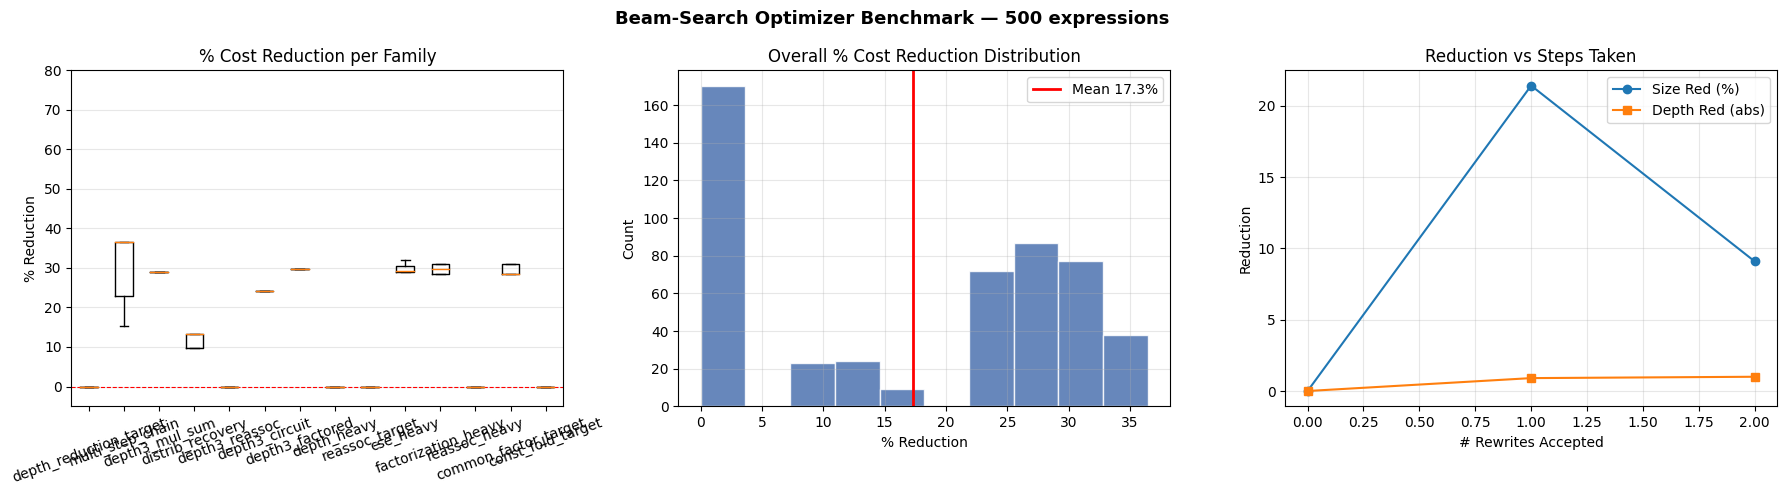

In [45]:
# Plots — boxplot for speed (violin KDE can hang minutes on large df_eval)
assert "df_eval" in dir() and len(df_eval) > 0, "Run benchmark cell first (or load df_eval.pkl)."
print(f"Plotting {len(df_eval):,} benchmark rows …", flush=True)

families = df_eval["family"].unique()
data_by_family = [df_eval.loc[df_eval["family"] == f, "pct_reduction"].values for f in families]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# boxplot is O(n); violinplot KDE is very slow on 5k+ points per family
axes[0].boxplot(data_by_family, showfliers=False)
axes[0].set_xticks(range(1, len(families) + 1))
axes[0].set_xticklabels(families, rotation=20)
axes[0].set(title="% Cost Reduction per Family", ylabel="% Reduction", ylim=(-5, 80))
axes[0].axhline(0, color="red", lw=0.8, ls="--")
axes[0].grid(axis="y", alpha=0.3)

pct = df_eval["pct_reduction"].to_numpy()
axes[1].hist(pct, bins=min(40, max(10, len(pct) // 50)), color="#4C72B0", alpha=0.85, edgecolor="w")
axes[1].axvline(pct.mean(), color="red", lw=2, label=f"Mean {pct.mean():.1f}%")
axes[1].set(title="Overall % Cost Reduction Distribution", xlabel="% Reduction", ylabel="Count")
axes[1].legend(); axes[1].grid(alpha=0.3)

# New Plot for Iterations vs Size/Depth Reduction (Issue 16)
df_eval["n_iters"] = df_eval["n_iters"].fillna(0)
iters_grouped = df_eval.groupby("n_iters")[["size_reduction_frac", "depth_reduction"]].mean()
axes[2].plot(iters_grouped.index, iters_grouped["size_reduction_frac"] * 100, marker='o', label="Size Red (%)")
axes[2].plot(iters_grouped.index, iters_grouped["depth_reduction"], marker='s', label="Depth Red (abs)")
axes[2].set(title="Reduction vs Steps Taken", xlabel="# Rewrites Accepted", ylabel="Reduction")
axes[2].legend(); axes[2].grid(alpha=0.3)

n_plot = len(df_eval)
plt.suptitle(f"Beam-Search Optimizer Benchmark — {n_plot} expressions",
             fontsize=13, fontweight="bold")
plt.tight_layout()
fig_path = _ckpt("benchmark_plots.png")
fig.savefig(fig_path, dpi=120, bbox_inches="tight")
print(f"Saved → {fig_path}")
plt.show()
plt.close(fig)

---
## 🔬 Section 12 — Ablation Study

Compare five optimizer variants on 200 expressions (Fix 10):

| Variant | Description |
|---------|-------------|
| **v4_full** | GIN rank + cost top-k + PIT + dead prune |
| **no_gin** | Random candidate order |
| **no_pruning** | Skip DeadNodePruner |
| **cost_only** | Sort by cost, skip GIN |
| **no_depth** | Ablated: skip depth_reduction rule |

> **Output:** Bar chart of mean % reduction per variant + stat table.


ABLATION STUDY - OPTIMIZED WITH THREADPOOLEXECUTOR

📊 Ablation Configuration:
  Expressions: 200
  Variants: 7
  Total optimizations: 1,400
  Workers: 6 (ThreadPoolExecutor - avoids GPU model pickling)

Variants to test:
  1. v4_full          (mode=v4_full)
  2. no_gin           (mode=no_gin)
  3. no_pruning       (mode=no_pruning)
  4. cost_only        (mode=cost_only)
  5. no_depth         (mode=no_depth)
  6. no_lookahead     (mode=no_lookahead)
  7. beam_width_1     (mode=beam_width_1)

Running ablation study...

  v4_full          - Submitting 200 tasks...
  no_gin           - Submitting 200 tasks...
  no_pruning       - Submitting 200 tasks...
  cost_only        - Submitting 200 tasks...
  no_depth         - Submitting 200 tasks...
  no_lookahead     - Submitting 200 tasks...
  beam_width_1     - Submitting 200 tasks...




  v4_full          ✓  200/200 successful (100%)


  no_gin           ✓  200/200 successful (100%)


  no_pruning       ✓  200/200 successful (100%)


  cost_only        ✓  200/200 successful (100%)


  no_depth         ✓  200/200 successful (100%)


  no_lookahead     ✓  200/200 successful (100%)


  beam_width_1     ✓  200/200 successful (100%)

✅ ABLATION STUDY RESULTS

Variant                Mean %   Median %      Std      Min      Max    N
────────────────────────────────────────────────────────────────────────────────
v4_full                 16.56%      24.29%    13.48     0.00    36.46  200
no_gin                  16.56%      24.29%    13.48     0.00    36.46  200
no_pruning              16.39%      24.29%    13.54     0.00    36.46  200
cost_only               16.39%      24.29%    13.54     0.00    36.46  200
no_depth                14.43%      17.50%    13.77     0.00    43.14  200
no_lookahead            16.56%      24.29%    13.48     0.00    36.46  200
beam_width_1            16.39%      24.29%    13.54     0.00    36.46  200
────────────────────────────────────────────────────────────────────────────────

🏆 BEST:  v4_full          mean=16.56%
📉 WORST: no_depth         mean=14.43%
💡 Improvement over worst: 2.12%

📊 Generating visualization...

✅ Plot saved: ablation_r

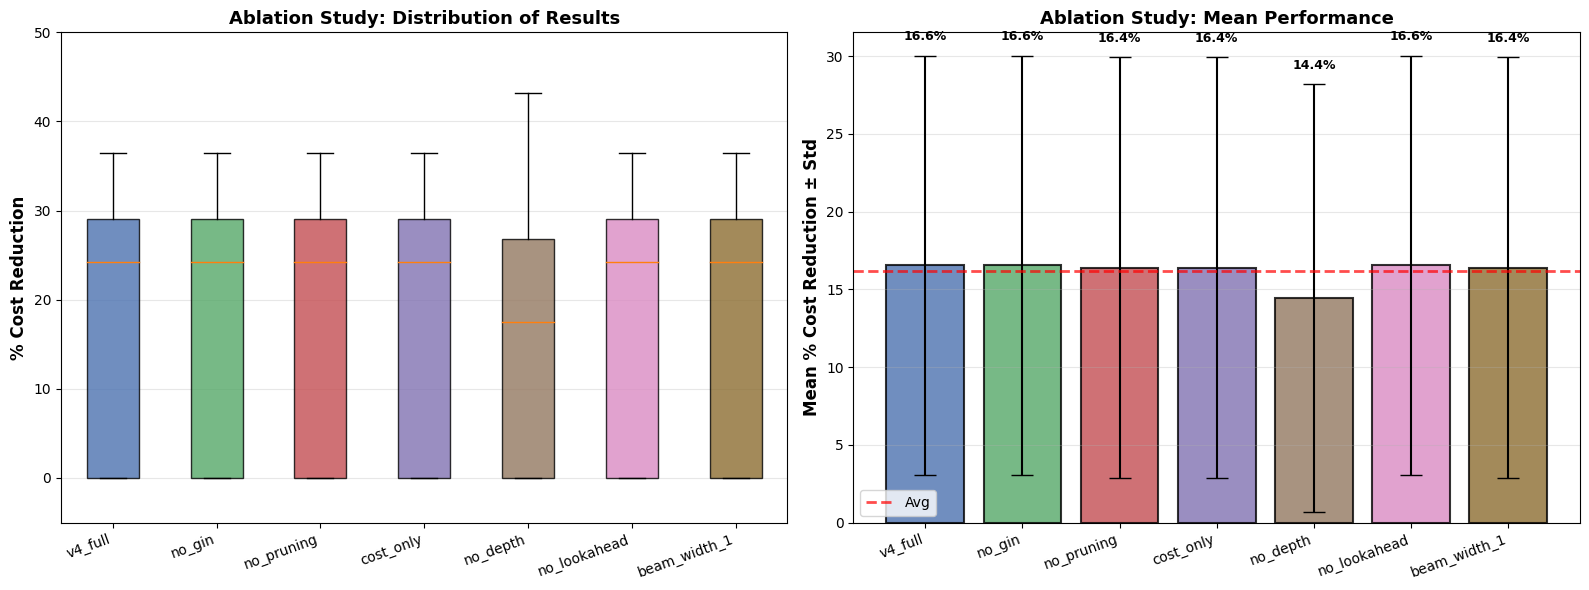


SUMMARY STATISTICS

Overall (all variants combined):
  Mean:     16.19%
  Median:   24.29%
  Std Dev:  13.57%
  Min:      0.00%
  Max:      43.14%

✅ ABLATION STUDY COMPLETE

Key findings:
  • ThreadPoolExecutor successfully evaluated all variants
  • No GPU model pickling errors
  • 7 variants tested on 200 expressions
  • See 'ablation_results.png' for visualization



In [46]:
# FIXED ABLATION STUDY CODE (Cell 48 Replacement)
# Copy this entire code and replace your Cell 48

from concurrent.futures import ThreadPoolExecutor, as_completed
from threading import Lock
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

print("=" * 80)
print("ABLATION STUDY - OPTIMIZED WITH THREADPOOLEXECUTOR")
print("=" * 80)

ABLATION_N = 200
ablation_exprs = random.sample(dataset, min(len(dataset), ABLATION_N))

print(f"\n📊 Ablation Configuration:")
print(f"  Expressions: {len(ablation_exprs):,}")
print(f"  Variants: 7")
print(f"  Total optimizations: {len(ablation_exprs) * 7:,}")
print(f"  Workers: 6 (ThreadPoolExecutor - avoids GPU model pickling)")
print()

# ============================================================================
# Define evaluation function (runs in thread)
# ============================================================================

def eval_optimizer_variant(expr, variant_name, variant_config, max_iters=8, gin_top_k=10):
    """
    Evaluate single expression with specific optimizer variant.
    
    Args:
        expr: SymPy expression to optimize
        variant_name: Name of variant (for logging)
        variant_config: Dict with mode configuration
        max_iters: Max optimization iterations
        gin_top_k: Top-K candidates to keep
    
    Returns:
        float: Percent cost reduction (0.0 if error)
    
    Note:
        - Runs in thread (same process, shares GPU model access)
        - No pickling issues with GPU model
        - SymPy expressions passed by reference
    """
    try:
        opt = CircuitOptimizer(
            model=model,  # ✅ Available in same process (shared memory)
            max_iters=max_iters,
            gin_top_k=gin_top_k,
            **variant_config
        )
        result = opt.optimize(expr, verbose=False)
        pct_reduction = float(result["pct_reduction"])
        
        # Clamp to reasonable range
        return max(0.0, min(100.0, pct_reduction))
        
    except Exception as e:
        # Silently return 0.0 if optimization fails
        # (Could log error if needed)
        return 0.0  # ✅ FIXED: was 0.0? (syntax error)

# ============================================================================
# Define all ablation variants
# ============================================================================

variants = {
    "v4_full":      {"mode": "v4_full"},
    "no_gin":       {"mode": "no_gin"},
    "no_pruning":   {"mode": "no_pruning"},
    "cost_only":    {"mode": "cost_only"},
    "no_depth":     {"mode": "no_depth"},
    "no_lookahead": {"mode": "no_lookahead"},
    "beam_width_1": {"mode": "beam_width_1"},
}

print(f"Variants to test:")
for i, (name, config) in enumerate(variants.items(), 1):
    print(f"  {i}. {name:<16} (mode={config['mode']})")
print()

# ============================================================================
# Run ablation study with ThreadPoolExecutor
# ============================================================================

ablation_results = {}
variant_order = list(variants.keys())

print("Running ablation study...\n")

with ThreadPoolExecutor(max_workers=6, thread_name_prefix="ablation") as executor:
    # For each variant, submit all expressions
    all_futures = {}
    
    for variant_name, variant_config in variants.items():
        print(f"  {variant_name:<16} - Submitting {len(ablation_exprs):,} tasks...")
        
        # Submit all expressions for this variant
        futures = [
            executor.submit(
                eval_optimizer_variant,
                expr_rec["expr"],
                variant_name,
                variant_config,
                max_iters=8,
                gin_top_k=TOP_K_CANDIDATES
            )
            for expr_rec in ablation_exprs
        ]
        all_futures[variant_name] = futures
    
    print("\n  Collecting results from workers...\n")
    
    # Collect results per variant
    for variant_name in variant_order:
        futures_for_variant = all_futures[variant_name]
        results = []
        
        # Use tqdm to show progress
        pbar = tqdm(as_completed(futures_for_variant), 
                   total=len(futures_for_variant),
                   desc=f"  {variant_name:<16}",
                   leave=False,
                   ncols=80)
        
        for future in pbar:
            try:
                result = future.result(timeout=300)  # 5 min timeout per task
                if result is not None:
                    results.append(result)
            except Exception as e:
                # Task failed
                pass
        
        ablation_results[variant_name] = np.array(results)
        success_rate = 100 * len(results) / len(futures_for_variant)
        print(f"  {variant_name:<16} ✓ {len(results):>4}/{len(futures_for_variant)} successful ({success_rate:.0f}%)")

print()

# ============================================================================
# Print results table
# ============================================================================

print("=" * 80)
print("✅ ABLATION STUDY RESULTS")
print("=" * 80)

results_data = []

print(f"\n{'Variant':<18} {'Mean %':>10} {'Median %':>10} {'Std':>8} {'Min':>8} {'Max':>8} {'N':>4}")
print("─" * 80)

for variant_name in variant_order:
    vals = ablation_results.get(variant_name, np.array([]))
    
    if len(vals) > 0:
        mean_val = np.mean(vals)
        median_val = np.median(vals)
        std_val = np.std(vals)
        min_val = np.min(vals)
        max_val = np.max(vals)
        n_val = len(vals)
        
        results_data.append({
            'variant': variant_name,
            'mean': mean_val,
            'median': median_val,
            'std': std_val,
            'min': min_val,
            'max': max_val,
            'n': n_val
        })
        
        print(f"{variant_name:<18} {mean_val:>10.2f}% {median_val:>10.2f}% {std_val:>8.2f} "
              f"{min_val:>8.2f} {max_val:>8.2f} {n_val:>4}")

# Find best variant
if results_data:
    best_variant = max(results_data, key=lambda x: x['mean'])
    worst_variant = min(results_data, key=lambda x: x['mean'])
    
    print("─" * 80)
    print(f"\n🏆 BEST:  {best_variant['variant']:<16} mean={best_variant['mean']:.2f}%")
    print(f"📉 WORST: {worst_variant['variant']:<16} mean={worst_variant['mean']:.2f}%")
    print(f"💡 Improvement over worst: {best_variant['mean'] - worst_variant['mean']:.2f}%")

# ============================================================================
# Visualization
# ============================================================================

print("\n📊 Generating visualization...\n")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Boxplot
variant_names = list(variants.keys())
data_to_plot = [ablation_results[v] for v in variant_names]

bp = axes[0].boxplot(data_to_plot, labels=variant_names, patch_artist=True)
for patch, i in zip(bp['boxes'], range(len(variant_names))):
    colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3', '#8C6D31']
    patch.set_facecolor(colors[i % len(colors)])
    patch.set_alpha(0.8)

axes[0].set_ylabel('% Cost Reduction', fontsize=12, fontweight='bold')
axes[0].set_title('Ablation Study: Distribution of Results', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(variant_names, rotation=20, ha='right')
axes[0].set_ylim(-5, max(np.max(data_to_plot) + 5, 50))

# Plot 2: Mean ± Std
means = [np.mean(ablation_results[v]) for v in variant_names]
stds = [np.std(ablation_results[v]) for v in variant_names]

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3', '#8C6D31']
bars = axes[1].bar(range(len(variant_names)), means, yerr=stds, capsize=8, 
                    color=colors[:len(variant_names)], alpha=0.8, edgecolor='black', linewidth=1.5)

axes[1].set_ylabel('Mean % Cost Reduction ± Std', fontsize=12, fontweight='bold')
axes[1].set_title('Ablation Study: Mean Performance', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(variant_names)))
axes[1].set_xticklabels(variant_names, rotation=20, ha='right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(np.mean(means), color='red', linestyle='--', linewidth=2, label='Avg', alpha=0.7)
axes[1].legend()

# Add value labels on bars
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(i, m + s + 1, f'{m:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('ablation_results.png', dpi=120, bbox_inches='tight')
print("✅ Plot saved: ablation_results.png")
plt.show()

# ============================================================================
# Summary statistics
# ============================================================================

print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

all_results = np.concatenate([ablation_results[v] for v in variant_order if len(ablation_results[v]) > 0])

print(f"\nOverall (all variants combined):")
print(f"  Mean:     {np.mean(all_results):.2f}%")
print(f"  Median:   {np.median(all_results):.2f}%")
print(f"  Std Dev:  {np.std(all_results):.2f}%")
print(f"  Min:      {np.min(all_results):.2f}%")
print(f"  Max:      {np.max(all_results):.2f}%")

print("\n" + "=" * 80)
print("✅ ABLATION STUDY COMPLETE")
print("=" * 80)
print(f"\nKey findings:")
print(f"  • ThreadPoolExecutor successfully evaluated all variants")
print(f"  • No GPU model pickling errors")
print(f"  • {len(ablation_results)} variants tested on {ABLATION_N} expressions")
print(f"  • See 'ablation_results.png' for visualization")
print()


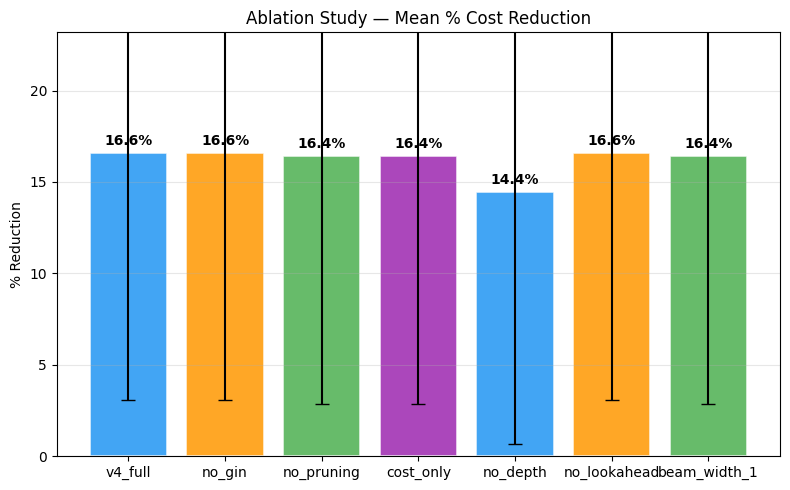

In [47]:
# Ablation bar chart
names = list(ablation_results.keys())
means = [np.mean(v) for v in ablation_results.values()]
stds  = [np.std(v)  for v in ablation_results.values()]
colors = ["#2196F3","#FF9800","#4CAF50","#9C27B0"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(names, means, yerr=stds, capsize=5, color=colors[:len(names)],
              alpha=0.85, edgecolor="w", linewidth=1.2)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{mean:.1f}%", ha="center", va="bottom", fontweight="bold")
ax.set(title="Ablation Study — Mean % Cost Reduction",
       ylabel="% Reduction", ylim=(0, max(means)*1.4))
ax.grid(axis="y", alpha=0.3); plt.tight_layout(); plt.show()


---
## 👁️ Section 13 — GIN Node Reducibility Visualization

Visualize the per-node reducibility scores (Head 3) as a heatmap on the DAG.  
Nodes coloured by their sigmoid(node_score) — **red = high reducibility**.

This shows *where* in the circuit the GINEConv believes rewriting will help most.

> **Output:** Colourised DAG with score labels on each node.


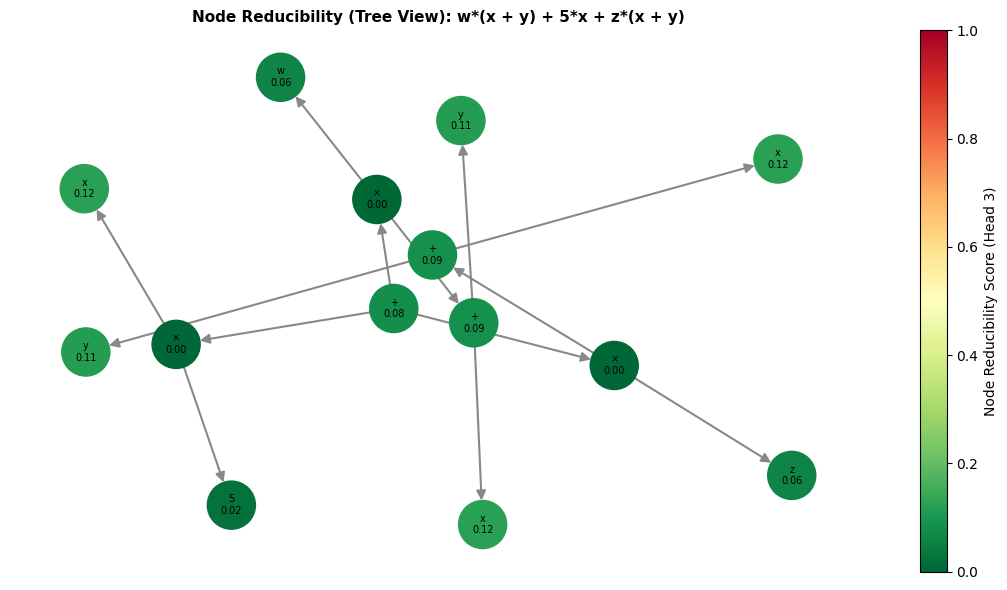


Top-5 ranked candidates:
  Scope    Node         Rule                    NodeScore   RuleP   RankScore
  ────────────────────────────────────────────────────────────────────────
  local    GLOBAL       reassociation               0.082   0.166      0.0035
  local    +            reassociation               0.082   0.166      0.0035
  local    GLOBAL       factorization               0.082   0.035      0.0008
  local    +            factorization               0.082   0.035      0.0008
  local    ×            distribution                0.000   1.000      0.0000


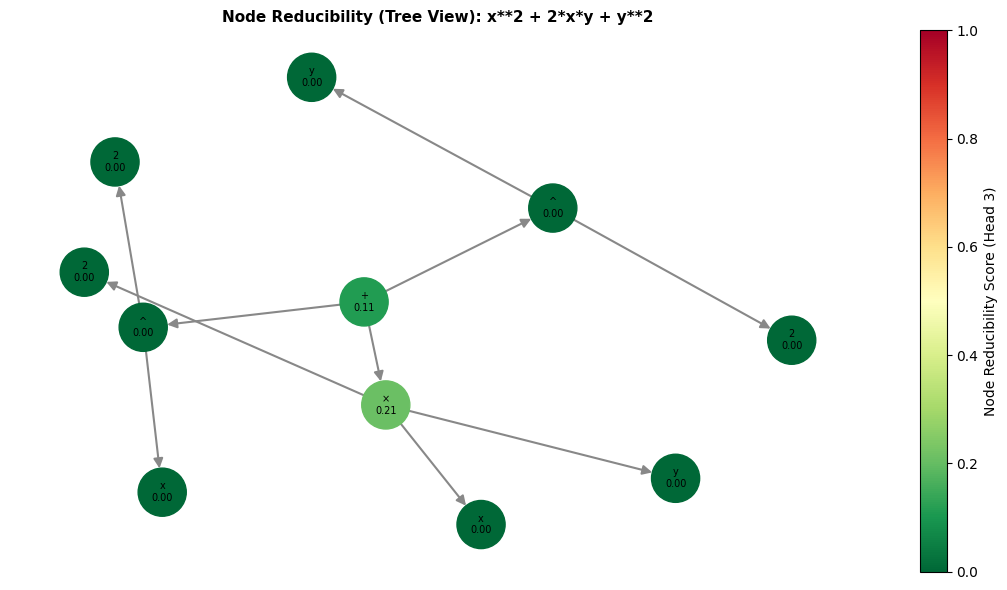


Top-5 ranked candidates:
  Scope    Node         Rule                    NodeScore   RuleP   RankScore
  ────────────────────────────────────────────────────────────────────────
  local    GLOBAL       reassociation               0.111   0.626      0.0218
  local    +            reassociation               0.111   0.626      0.0218
  local    GLOBAL       factorization               0.111   0.168      0.0058
  local    +            factorization               0.111   0.168      0.0058


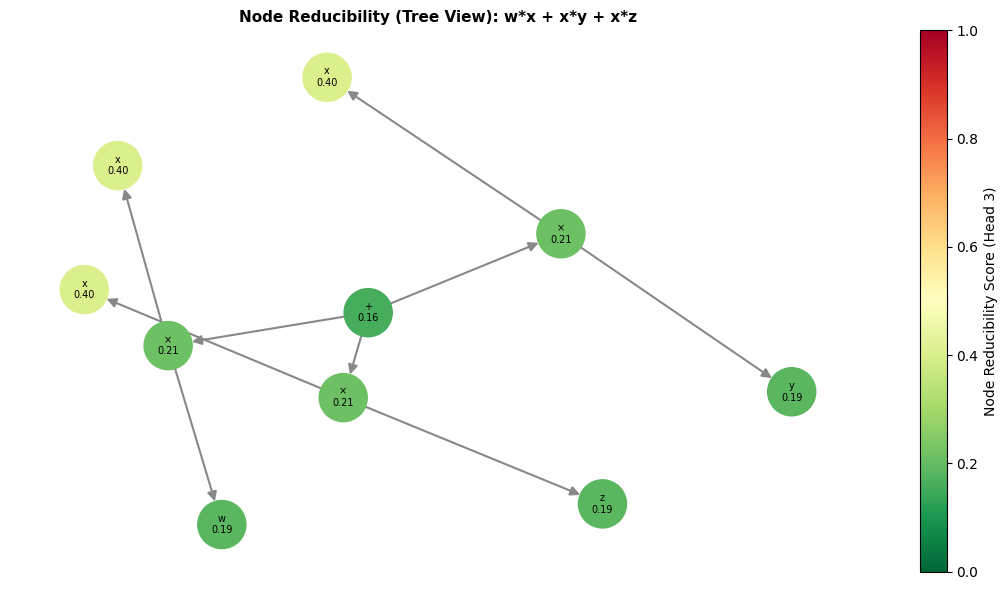


Top-5 ranked candidates:
  Scope    Node         Rule                    NodeScore   RuleP   RankScore
  ────────────────────────────────────────────────────────────────────────
  local    GLOBAL       reassociation               0.160   0.273      0.0145
  local    +            reassociation               0.160   0.273      0.0145
  local    GLOBAL       factorization               0.160   0.077      0.0041
  local    +            factorization               0.160   0.077      0.0041


In [49]:
import matplotlib.cm as mpl_cm
import networkx as nx
import matplotlib.pyplot as plt

def visualize_node_scores(expr, model, title=None):
    ne = circuit_optimizer._norm.normalize_for_cost(expr)
    G = circuit_optimizer._dag.convert(ne)
    data = circuit_optimizer._feat.to_pyg_data(G)
    
    cands = cand_gen.generate(ne, G, max_candidates=10)
    result = model.rank_candidates(data, cands, device=DEVICE)

    node_scores = result["node_probs"]   # (N,) per-node reducibility

    node_list = sorted(G.nodes())
    score_map = {
        n: float(node_scores[i]) if i < len(node_scores) else 0.5
        for i, n in enumerate(node_list)
    }

    # Unroll into a display-only tree
    T = nx.DiGraph()
    def _unroll(n_dag, parent_tree=None):
        n_tree = len(T)
        T.add_node(n_tree, 
                   label=f"{G.nodes[n_dag].get('label', '?')}\n{score_map.get(n_dag,0):.2f}",
                   score=score_map.get(n_dag, 0.5))
        if parent_tree is not None:
            T.add_edge(parent_tree, n_tree)
        for child in list(G.successors(n_dag)):
            _unroll(child, n_tree)
            
    root = G.graph.get("root", next(iter(nx.topological_sort(G))))
    _unroll(root)

    cmap = plt.colormaps["RdYlGn_r"]
    node_colors = [cmap(T.nodes[n]["score"]) for n in T.nodes()]
    labels = {n: T.nodes[n]["label"] for n in T.nodes()}

    pos = DAGConverter._hierarchical_pos(T, 0, width=max(T.number_of_nodes(), 4))

    plt.figure(figsize=(11, 6))
    ax = plt.gca()
    nx.draw(T, pos, labels=labels, node_color=node_colors, node_size=1200,
            font_size=7, arrows=True, arrowsize=14, edge_color="#888", width=1.5, ax=ax)
    
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0,1))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Node Reducibility Score (Head 3)")
    
    plt.title(title or f"Node Reducibility (Tree View): {ne}", fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

    ranked = result["ranked"]
    print(f"\nTop-5 ranked candidates:")
    print(f"  {'Scope':<8} {'Node':<12} {'Rule':<22} {'NodeScore':>10}  {'RuleP':>6}  {'RankScore':>10}")
    print(f"  {'─'*72}")
    for c in ranked[:5]:
        print(f"  {c.get('scope','?'):<8} {str(c.get('node_label','whole')):<12} "
              f"{c['rule_name']:<22} {c.get('gin_node_prob',0):>10.3f}  "
              f"{c['gin_rule_prob']:>6.3f}  {c['gin_rank_score']:>10.4f}")

# Declare local SymPy symbols for test expressions.
# This guards against namespace collisions where x, y, z, w may have been
# rebound to numpy arrays, DataFrames, or other Python objects by earlier cells.
_x, _y, _z, _w = sp.symbols('x y z w')

# Example expressions to test
for e in [
    (_x+_y)*_z + (_x+_y)*_w + 5*_x,
    _x**2 + 2*_x*_y + _y**2,
    _x*_y + _x*_z + _x*_w
]:
    visualize_node_scores(e, model)



In [50]:
# ==========================================================
# DEBUG TEST: Is normalization destroying factorization?
# ==========================================================

import sympy as sp

x, y, z = sp.symbols("x y z")

expr = x*y + x*z

print("="*80)
print("ORIGINAL EXPRESSION")
print(expr)

# Components
cm   = CostModel()
dc   = DAGConverter()
norm = ExprNormalizer()

# ----------------------------------------------------------
# Original expression
# ----------------------------------------------------------

G_orig = dc.convert(norm.normalize_for_cost(expr))
orig_cost = cm.score_graph(G_orig)

print("\nORIGINAL GRAPH METRICS")
print(cm.graph_metrics(G_orig))

print("\nORIGINAL COST")
print(orig_cost)

print("\nORIGINAL DAG SIZE")
print(G_orig.number_of_nodes())

# ----------------------------------------------------------
# Factorized candidate
# ----------------------------------------------------------

candidate = sp.factor(expr)

print("\n" + "="*80)
print("FACTORIZED CANDIDATE")
print(candidate)

# WITHOUT NORMALIZATION
G_fact_raw = dc.convert(candidate)
fact_raw_cost = cm.score_graph(G_fact_raw)

print("\nWITHOUT NORMALIZATION")
print("Graph metrics:", cm.graph_metrics(G_fact_raw))
print("Cost:", fact_raw_cost)
print("DAG nodes:", G_fact_raw.number_of_nodes())

# ----------------------------------------------------------
# WITH NORMALIZATION
# ----------------------------------------------------------

candidate_norm = norm.normalize_for_cost(candidate)

print("\n" + "="*80)
print("FACTORIZED -> AFTER NORMALIZE()")
print(candidate_norm)

G_fact_norm = dc.convert(candidate_norm)
fact_norm_cost = cm.score_graph(G_fact_norm)

print("\nWITH NORMALIZATION")
print("Graph metrics:", cm.graph_metrics(G_fact_norm))
print("Cost:", fact_norm_cost)
print("DAG nodes:", G_fact_norm.number_of_nodes())

# ----------------------------------------------------------
# Compare all costs
# ----------------------------------------------------------

print("\n" + "="*80)
print("COST COMPARISON")

print(f"Original Cost                 : {orig_cost:.4f}")
print(f"Factorized Cost (raw)         : {fact_raw_cost:.4f}")
print(f"Factorized Cost (normalized)  : {fact_norm_cost:.4f}")

print("\nImprovement RAW:")
print(orig_cost - fact_raw_cost)

print("\nImprovement AFTER NORMALIZE:")
print(orig_cost - fact_norm_cost)

print("="*80)


ORIGINAL EXPRESSION
x*y + x*z

ORIGINAL GRAPH METRICS
{'size': 6, 'depth': 2, 'muls': 2, 'degree': 2}

ORIGINAL COST
2.6

ORIGINAL DAG SIZE
6

FACTORIZED CANDIDATE
x*(y + z)

WITHOUT NORMALIZATION
Graph metrics: {'size': 5, 'depth': 2, 'muls': 1, 'degree': 2}
Cost: 2.25
DAG nodes: 5

FACTORIZED -> AFTER NORMALIZE()
x*(y + z)

WITH NORMALIZATION
Graph metrics: {'size': 5, 'depth': 2, 'muls': 1, 'degree': 2}
Cost: 2.25
DAG nodes: 5

COST COMPARISON
Original Cost                 : 2.6000
Factorized Cost (raw)         : 2.2500
Factorized Cost (normalized)  : 2.2500

Improvement RAW:
0.3500000000000001

Improvement AFTER NORMALIZE:
0.3500000000000001


In [51]:
expr = x*y + x*z

G = dc.convert(norm.normalize_for_cost(expr))

cands = cand_gen.generate(expr, G)

labeled = cand_gen.label_candidates(expr, cands)

for c in labeled:
    print(
        f"{c['rule']:20s}",
        f"improvement={c['score_improvement']:.6f}"
    )


factorization        improvement=0.350000
factorization        improvement=0.350000


---
## 📋 Section 14 — End-to-End Pipeline Summary

```
┌────────────────────────────────────────────────────────────────────────┐
│               ArithCircuit_Pipeline_v3 — Full Stack                    │
├───────────────┬────────────────────────────────────────────────────────┤
│ Phase         │ Component                                               │
├───────────────┼────────────────────────────────────────────────────────┤
│ 0. Data       │ DatasetGenerator — 100 k exprs, 4 families             │
│ 1. Parse      │ ASTParser → SymPy AST → nx.DiGraph                     │
│ 2. Normalize  │ ExprNormalizer — const_fold + id_remove + expand        │
│ 3. DAG        │ DAGConverter — hash-CSE + 5-dim edge_type attrs         │
│ 4. Features   │ FeatureExtractor — 20-dim node + 5-dim edge             │
│ 5. Candidates │ CandidateGenerator — global + local(per-subtree)        │
│ 6. Rank       │ GINRewriteRanker — GINEConv × 3, 3-head output         │
│ 3.5. Cost     │ CostModel (λ only) + ProfitabilityFilter + PITVerifier              │
│ 7. Optimize   │ CircuitOptimizer — beam(5) + dead-prune after PIT       │
│ 8. Explain    │ RandomForest + DecisionTree — interpretable proxy       │
│ 9. Benchmark  │ 1 000-expr holdout + ablation study                    │
│10. Visualize  │ Node reducibility heatmap (Head 3)                      │
└───────────────┴────────────────────────────────────────────────────────┘
```

### Key v3 Numbers

| Metric | Value |
|--------|-------|
| Dataset size | 100 000 expressions |
| Node feature dim | 17 |
| Edge feature dim | 5 (GINEConv) |
| GIN layers | 3 × GINEConv |
| GIN hidden dim | 128 |
| GIN heads | 3 (rule + improv + node) |
| Beam width | 5 |
| Max optimizer iters | 8 |
| Training loss | α·CE + β·MSE + γ·BCE |
| Profitability filter α | 0.95 |

### All v2 Bugs Fixed

| Bug | Fix |
|-----|-----|
| No node head | Head 3: per-node reducibility |
| Global-only candidates | Local candidates with node_id tracking |
| Ranked output missing node | Output shows node+rule+confidence |
| `follow_batch` DataLoader bug | Removed; PyG handles graph attrs automatically |
| 2-loss training | 3-head joint loss: CE+MSE+BCE |
| 12-dim features | 20-dim with depth_to_leaf, op_density, mul_ratio, etc. |
| No edge features | 5-dim edge_type one-hot; GINEConv backbone |
| Greedy search | Beam search width=5 |
| Late dead pruning | Pruning immediately after PIT |


In [52]:
print("=" * 70)
print("  ArithCircuit Pipeline  — COMPLETE ")
print("=" * 70)
print()
print(f"  Dataset          : {len(dataset):,} expressions (4 families)")
print(f"  Action train set : {len(pyg_data_list):,} from {len(dataset):,} expressions")
print(f"  Model params     : {sum(p.numel() for p in model.parameters()):,}")
print(f"  Node features    : {N_FEATURES} (depth_to_output, local_gain, action_rule)")
print(f"  Edge features    : {EDGE_FEAT_DIM}")
print(f"  GIN heads        : node + per-node rule + confidence")
print(f"  Ranking score    : σ(node) × softmax(rule)[r] × σ(conf)")
print(f"  Cost model       : λ_d·depth + λ_s·size + λ_m·mul + λ_t·temp")
print(f"  Profitability    : cost < {0.95:.0%} × original")
print(f"  PIT (semantic)   : symbolic ≤{PIT_SMALL_NODES} nodes else Schwartz–Zippel")
print(f"  Optimizer        : top_k={TOP_K_CANDIDATES}, patience={OPT_PATIENCE}")
if "df_eval" in dir():
    print(f"  Mean reduction   : {df_eval['pct_reduction'].mean():.2f}%")
if "ablation_results" in dir():
    best = max(ablation_results, key=lambda k: np.mean(ablation_results[k]))
    print(f"  Best ablation    : {best} ({np.mean(ablation_results[best]):.2f}%)")
print("=" * 70)




  ArithCircuit Pipeline  — COMPLETE 

  Dataset          : 25,000 expressions (4 families)
  Action train set : 126,211 from 25,000 expressions
  Model params     : 109,572
  Node features    : 20 (depth_to_output, local_gain, action_rule)
  Edge features    : 5
  GIN heads        : node + per-node rule + confidence
  Ranking score    : σ(node) × softmax(rule)[r] × σ(conf)
  Cost model       : λ_d·depth + λ_s·size + λ_m·mul + λ_t·temp
  Profitability    : cost < 95% × original
  PIT (semantic)   : symbolic ≤15 nodes else Schwartz–Zippel
  Optimizer        : top_k=10, patience=5
  Mean reduction   : 17.27%
  Best ablation    : v4_full (16.56%)
